# Single-Cell DNA Methylation Heterogeneity Analysis

## Project Overview

This project investigates observed DNA methylation variability at the single-cell level using single-cell bisulfite sequencing (scBS-seq) data from mouse muscle stem cells.

The analysis focuses on:
- Processing CpG-level methylation data from `.cov.gz` files
- Assessing CpG coverage across individual cells
- Quantifying observed methylation variability across cells
- Comparing methylation variability between young and old samples
- Exploring cell-level methylation profile divergence
- Evaluating reproducibility of observed variability across biological samples

## Dataset

Data were obtained from GEO accession **GSE121436**, which contains single-cell DNA methylation sequencing data from mouse muscle stem cells.

The study includes young and old mice, allowing exploration of age-associated patterns in DNA methylation variability.

## Important Note

Because single-cell methylation data are sparse and biological replicates are represented by individual mice, the analyses in this project are primarily exploratory and descriptive. Observed variability should not automatically be interpreted as definitive biological heterogeneity or an age effect.

Missing CpG observations are retained as missing values rather than being treated as unmethylated.

## Analysis Workflow

1. Data acquisition and file validation
2. CpG coverage assessment
3. Construction of methylation matrices
4. Quantification of CpG-level methylation variability
5. Cell-level methylation profile comparison
6. Comparison of young and old samples
7. Cross-sample comparison using shared high-coverage CpGs
8. Visualization and statistical exploration

## Reproducibility

The original analysis notebook is retained as part of the project record. A cleaned and documented version can be developed separately after the initial analysis.

In [ ]:
!wget -O GSM3436261_O1_TA_Hi_10.cov.gz "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436261/suppl/GSM3436261_O1_TA_Hi_10.cov.gz"

--2026-10-04 07:23:03--  https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436261/suppl/GSM3436261_O1_TA_Hi_10.cov.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8806553 (8.4M) [application/x-gzip]
Saving to: ‘GSM3436261_O1_TA_Hi_10.cov.gz’

GSM3436261_O1_TA_Hi 100%[===================>]   8.40M  52.5MB/s    in 0.2s    

2026-10-04 07:23:03 (52.5 MB/s) - ‘GSM3436261_O1_TA_Hi_10.cov.gz’ saved [8806553/8806553]



In [ ]:
import os
print(os.path.exists("GSM3436261_O1_TA_Hi_10.cov.gz"))
print(os.path.getsize("GSM3436261_O1_TA_Hi_10.cov.gz") if os.path.exists("GSM3436261_O1_TA_Hi_10.cov.gz") else "Download failed")

True
8806553


In [ ]:
import os

file = "GSM3436261_O1_TA_Hi_10.cov.gz"

print("Exists:", os.path.exists(file))
print("Size:", os.path.getsize(file) / (1024**2), "MB")

Exists: True
Size: 8.39858341217041 MB


In [ ]:

!wget -c --tries=10 --timeout=30 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz" \
-O /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz

--2026-10-04 07:26:28--  https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::12, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10550 (10K) [application/x-gzip]
Saving to: ‘/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz’

/content/methylatio 100%[===================>]  10.30K  --.-KB/s    in 0s      

2026-10-04 07:26:29 (132 MB/s) - ‘/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz’ saved [10550/10550]



In [ ]:
import os

f = "/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz"

print("Exists:", os.path.exists(f))
if os.path.exists(f):
    print("Size:", os.path.getsize(f) / (1024**2), "MB")

Exists: True
Size: 0.010061264038085938 MB


In [ ]:
import os

f = "/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz"

print(os.path.getsize(f))

10550


In [ ]:
import os
os.remove("/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz")

In [ ]:
!wget --retry-connrefused --waitretry=5 --tries=20 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz" \
-O /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz

--2026-10-04 07:28:10--  https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 2607:f220:41e:250::10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10550 (10K) [application/x-gzip]
Saving to: ‘/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz’

/content/methylatio 100%[===================>]  10.30K  --.-KB/s    in 0s      

2026-10-04 07:28:10 (72.9 MB/s) - ‘/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz’ saved [10550/10550]



In [ ]:
import os

f = "/content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz"
print("Size:", os.path.getsize(f) / (1024**2), "MB")

Size: 0.010061264038085938 MB


In [ ]:
import requests

url = "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz"

r = requests.get(url, allow_redirects=True)

print("Status:", r.status_code)
print("Final URL:", r.url)
print("Content-Type:", r.headers.get("Content-Type"))
print("Content-Length:", r.headers.get("Content-Length"))
print("First 200 bytes:", r.content[:200])

ChunkedEncodingError: ('Connection broken: IncompleteRead(0 bytes read, 10550 more expected)', IncompleteRead(0 bytes read, 10550 more expected))

In [ ]:
!curl -I --max-time 30 "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz"

HTTP/1.1 200 OK
Date: Sun, 04 Oct 2026 07:29:17 GMT
Server: Apache
Last-Modified: Thu, 27 Sep 2018 10:44:07 GMT
Accept-Ranges: bytes
Content-Length: 10550
Cache-Control: public, max-age=86400
Expires: Sun, 11 Oct 2026 07:29:17 GMT
Strict-Transport-Security: max-age=31536000; includeSubDomains; preload
Access-Control-Allow-Origin: *
Access-Control-Allow-Methods: GET,POST,PUT,OPTIONS
Access-Control-Allow-Headers: RANGE, Cache-control, If-None-Match, Content-Type
Access-Control-Expose-Headers: Content-Length, Content-Range, Content-Type
Content-Type: application/x-gzip



In [ ]:
!curl -L --fail --retry 5 --retry-delay 3 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz" \
-o /content/methylation_data/GSM3436305_O8_TA_Hi_11.cov.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 19470    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
curl: (18) transfer closed with 19470 bytes remaining to read


In [ ]:
import os

f = "/content/methylation_data/GSM3436305_O8_TA_Hi_11.cov.gz"
print("Size:", os.path.getsize(f) / (1024**2), "MB")

FileNotFoundError: [Errno 2] No such file or directory: '/content/methylation_data/GSM3436305_O8_TA_Hi_11.cov.gz'

In [ ]:
!mkdir -p /content/methylation_data

!curl -L --fail --retry 5 --retry-delay 3 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz" \
-o /content/methylation_data/GSM3436305_O8_TA_Hi_11.cov.gz

!ls -lh /content/methylation_data/GSM3436305_O8_TA_Hi_11.cov.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 19470    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
curl: (18) transfer closed with 19470 bytes remaining to read
ls: cannot access '/content/methylation_data/GSM3436305_O8_TA_Hi_11.cov.gz': No such file or directory


In [ ]:
!curl -I "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz"

HTTP/1.1 200 OK
Date: Sun, 04 Oct 2026 07:32:38 GMT
Server: Apache
Last-Modified: Thu, 27 Sep 2018 10:37:14 GMT
Accept-Ranges: bytes
Content-Length: 19470
Cache-Control: public, max-age=86400
Expires: Sun, 11 Oct 2026 07:32:38 GMT
Strict-Transport-Security: max-age=31536000; includeSubDomains; preload
Access-Control-Allow-Origin: *
Access-Control-Allow-Methods: GET,POST,PUT,OPTIONS
Access-Control-Allow-Headers: RANGE, Cache-control, If-None-Match, Content-Type
Access-Control-Expose-Headers: Content-Length, Content-Range, Content-Type
Content-Type: application/x-gzip



In [ ]:
!curl -L --fail --range 0-9999 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz" \
-o /content/part1

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 10000    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
curl: (18) transfer closed with 10000 bytes remaining to read


In [ ]:
!ls -lh /content/part1

ls: cannot access '/content/part1': No such file or directory


In [ ]:
!gzip -t /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz && echo "VALID GZIP" || echo "CORRUPTED"

VALID GZIP


In [ ]:
!zcat /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz | head

1	6823411	6823411	100.00	1	0
1	8397783	8397783	0.00	0	1
1	11466117	11466117	0.00	0	1
1	22373851	22373851	100.00	1	0
1	23337673	23337673	100.00	1	0
1	24286929	24286929	100.00	1	0
1	27314398	27314398	100.00	2	0
1	32270139	32270139	100.00	2	0
1	32955113	32955113	100.00	1	0
1	33923080	33923080	0.00	0	1


In [ ]:
!zcat /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz | wc -l

1476


In [ ]:
!curl -L --retry 10 --retry-delay 2 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz" \
-o /content/GSM3436305_O8_TA_Hi_11.cov.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 19470  100 19470    0     0   240k      0 --:--:-- --:--:-- --:--:--  243k


In [ ]:
!gzip -t /content/GSM3436305_O8_TA_Hi_11.cov.gz && echo "VALID GZIP"

VALID GZIP


In [ ]:
!zcat /content/GSM3436305_O8_TA_Hi_11.cov.gz | wc -l

2674


In [ ]:
import os
import subprocess

files = [
    ("GSM3436304", "GSM3436304_O8_TA_Hi_10.cov.gz"),
    ("GSM3436305", "GSM3436305_O8_TA_Hi_11.cov.gz"),
    ("GSM3436306", "GSM3436306_O8_TA_Hi_12.cov.gz"),
    ("GSM3436307", "GSM3436307_O8_TA_Hi_13.cov.gz"),
    ("GSM3436308", "GSM3436308_O8_TA_Hi_14.cov.gz"),
    ("GSM3436309", "GSM3436309_O8_TA_Hi_15.cov.gz"),
    ("GSM3436310", "GSM3436310_O8_TA_Hi_16.cov.gz"),
    ("GSM3436311", "GSM3436311_O8_TA_Hi_17.cov.gz"),
    ("GSM3436312", "GSM3436312_O8_TA_Hi_18.cov.gz"),
    ("GSM3436313", "GSM3436313_O8_TA_Hi_19.cov.gz"),
]

os.makedirs("/content/methylation_data", exist_ok=True)

for gsm, filename in files:
    url = f"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/{gsm}/suppl/{filename}"
    output = f"/content/methylation_data/{filename}"

    if os.path.exists(output):
        print("Already exists:", filename)
        continue

    print("Downloading:", filename)

    result = subprocess.run([
        "curl", "-L",
        "--retry", "10",
        "--retry-delay", "2",
        "--fail",
        url,
        "-o", output
    ])

    if result.returncode == 0:
        print("✓ Done")
    else:
        print("✗ Failed")

print("Finished.")

Already exists: GSM3436304_O8_TA_Hi_10.cov.gz
Downloading: GSM3436305_O8_TA_Hi_11.cov.gz
✓ Done
Downloading: GSM3436306_O8_TA_Hi_12.cov.gz
✓ Done
Downloading: GSM3436307_O8_TA_Hi_13.cov.gz
✓ Done
Downloading: GSM3436308_O8_TA_Hi_14.cov.gz
✓ Done
Downloading: GSM3436309_O8_TA_Hi_15.cov.gz
✓ Done
Downloading: GSM3436310_O8_TA_Hi_16.cov.gz
✓ Done
Downloading: GSM3436311_O8_TA_Hi_17.cov.gz
✓ Done
Downloading: GSM3436312_O8_TA_Hi_18.cov.gz
✓ Done
Downloading: GSM3436313_O8_TA_Hi_19.cov.gz
✓ Done
Finished.


In [ ]:
import os
import gzip

folder = "/content/methylation_data"

for filename in sorted(os.listdir(folder)):
    if filename.endswith(".cov.gz"):
        path = os.path.join(folder, filename)

        try:
            with gzip.open(path, "rt") as f:
                rows = sum(1 for _ in f)

            size_mb = os.path.getsize(path) / (1024**2)

            print(f"{filename}")
            print(f"  Size: {size_mb:.3f} MB")
            print(f"  CpG records: {rows}")
            print("  Status: VALID\n")

        except Exception as e:
            print(f"{filename}")
            print("  Status: ERROR:", e)

GSM3436261_O1_TA_Hi_10.cov.gz
  Size: 8.399 MB
  CpG records: 1609698
  Status: VALID

GSM3436262_O1_TA_Hi_11.cov.gz
  Size: 0.000 MB
  CpG records: 0
  Status: VALID

GSM3436304_O8_TA_Hi_10.cov.gz
  Size: 0.010 MB
  CpG records: 1476
  Status: VALID

GSM3436305_O8_TA_Hi_11.cov.gz
  Size: 0.019 MB
  CpG records: 2674
  Status: VALID

GSM3436306_O8_TA_Hi_12.cov.gz
  Size: 0.019 MB
  CpG records: 2769
  Status: VALID

GSM3436307_O8_TA_Hi_13.cov.gz
  Size: 0.022 MB
  CpG records: 3180
  Status: VALID

GSM3436308_O8_TA_Hi_14.cov.gz
  Size: 0.021 MB
  CpG records: 2990
  Status: VALID

GSM3436309_O8_TA_Hi_15.cov.gz
  Size: 0.019 MB
  CpG records: 2734
  Status: VALID

GSM3436310_O8_TA_Hi_16.cov.gz
  Size: 0.023 MB
  CpG records: 3336
  Status: VALID

GSM3436311_O8_TA_Hi_17.cov.gz
  Size: 0.025 MB
  CpG records: 3655
  Status: VALID

GSM3436312_O8_TA_Hi_18.cov.gz
  Size: 0.037 MB
  CpG records: 5987
  Status: VALID

GSM3436313_O8_TA_Hi_19.cov.gz
  Size: 9.871 MB
  CpG records: 1931328
  Stat

In [ ]:
import os
import gzip

folder = "/content/methylation_data"

for filename in sorted(os.listdir(folder)):
    if filename.startswith("GSM34363") and filename.endswith(".cov.gz"):
        path = os.path.join(folder, filename)

        with gzip.open(path, "rt") as f:
            rows = sum(1 for _ in f)

        print(filename, "→", rows, "CpGs")

GSM3436304_O8_TA_Hi_10.cov.gz → 1476 CpGs
GSM3436305_O8_TA_Hi_11.cov.gz → 2674 CpGs
GSM3436306_O8_TA_Hi_12.cov.gz → 2769 CpGs
GSM3436307_O8_TA_Hi_13.cov.gz → 3180 CpGs
GSM3436308_O8_TA_Hi_14.cov.gz → 2990 CpGs
GSM3436309_O8_TA_Hi_15.cov.gz → 2734 CpGs
GSM3436310_O8_TA_Hi_16.cov.gz → 3336 CpGs
GSM3436311_O8_TA_Hi_17.cov.gz → 3655 CpGs
GSM3436312_O8_TA_Hi_18.cov.gz → 5987 CpGs
GSM3436313_O8_TA_Hi_19.cov.gz → 1931328 CpGs


In [ ]:
!zcat /content/methylation_data/GSM3436313_O8_TA_Hi_19.cov.gz | head

1	3009073	3009073	100.00	1	0
1	3020724	3020724	100.00	1	0
1	3020794	3020794	0.00	0	1
1	3020795	3020795	100.00	1	0
1	3020815	3020815	100.00	1	0
1	3020843	3020843	100.00	1	0
1	3022043	3022043	0.00	0	1
1	3025008	3025008	0.00	0	1
1	3032862	3032862	0.00	0	1
1	3037279	3037279	0.00	0	1


In [ ]:
!zcat /content/methylation_data/GSM3436313_O8_TA_Hi_19.cov.gz | wc -l

1931328


In [ ]:
!zcat /content/methylation_data/GSM3436313_O8_TA_Hi_19.cov.gz | head -5

1	3009073	3009073	100.00	1	0
1	3020724	3020724	100.00	1	0
1	3020794	3020794	0.00	0	1
1	3020795	3020795	100.00	1	0
1	3020815	3020815	100.00	1	0


In [ ]:
import os
import gzip

folder = "/content/methylation_data"

results = []

for filename in sorted(os.listdir(folder)):
    if filename.endswith(".cov.gz"):
        path = os.path.join(folder, filename)

        with gzip.open(path, "rt") as f:
            n = sum(1 for _ in f)

        results.append((filename, n))

for filename, n in results:
    print(f"{filename}: {n:,} CpGs")

GSM3436261_O1_TA_Hi_10.cov.gz: 1,609,698 CpGs
GSM3436262_O1_TA_Hi_11.cov.gz: 0 CpGs
GSM3436304_O8_TA_Hi_10.cov.gz: 1,476 CpGs
GSM3436305_O8_TA_Hi_11.cov.gz: 2,674 CpGs
GSM3436306_O8_TA_Hi_12.cov.gz: 2,769 CpGs
GSM3436307_O8_TA_Hi_13.cov.gz: 3,180 CpGs
GSM3436308_O8_TA_Hi_14.cov.gz: 2,990 CpGs
GSM3436309_O8_TA_Hi_15.cov.gz: 2,734 CpGs
GSM3436310_O8_TA_Hi_16.cov.gz: 3,336 CpGs
GSM3436311_O8_TA_Hi_17.cov.gz: 3,655 CpGs
GSM3436312_O8_TA_Hi_18.cov.gz: 5,987 CpGs
GSM3436313_O8_TA_Hi_19.cov.gz: 1,931,328 CpGs


In [ ]:
!zcat /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz | head -20

1	6823411	6823411	100.00	1	0
1	8397783	8397783	0.00	0	1
1	11466117	11466117	0.00	0	1
1	22373851	22373851	100.00	1	0
1	23337673	23337673	100.00	1	0
1	24286929	24286929	100.00	1	0
1	27314398	27314398	100.00	2	0
1	32270139	32270139	100.00	2	0
1	32955113	32955113	100.00	1	0
1	33923080	33923080	0.00	0	1
1	36546241	36546241	0.00	0	1
1	37382364	37382364	0.00	0	1
1	38174453	38174453	100.00	1	0
1	47031783	47031783	100.00	1	0
1	51132239	51132239	100.00	1	0
1	56488375	56488375	100.00	1	0
1	57144063	57144063	0.00	0	1
1	59768212	59768212	100.00	2	0
1	61277368	61277368	100.00	1	0
1	61277371	61277371	100.00	1	0


In [ ]:
!zcat /content/methylation_data/GSM3436313_O8_TA_Hi_19.cov.gz | head -20

1	3009073	3009073	100.00	1	0
1	3020724	3020724	100.00	1	0
1	3020794	3020794	0.00	0	1
1	3020795	3020795	100.00	1	0
1	3020815	3020815	100.00	1	0
1	3020843	3020843	100.00	1	0
1	3022043	3022043	0.00	0	1
1	3025008	3025008	0.00	0	1
1	3032862	3032862	0.00	0	1
1	3037279	3037279	0.00	0	1
1	3038088	3038088	100.00	1	0
1	3038123	3038123	0.00	0	1
1	3059989	3059989	0.00	0	2
1	3059998	3059998	100.00	2	0
1	3060019	3060019	100.00	2	0
1	3061337	3061337	100.00	1	0
1	3061369	3061369	100.00	1	0
1	3061389	3061389	100.00	1	0
1	3065032	3065032	0.00	0	1
1	3065190	3065190	100.00	2	0


In [ ]:
!zcat /content/methylation_data/GSM3436304_O8_TA_Hi_10.cov.gz | head -20

1	6823411	6823411	100.00	1	0
1	8397783	8397783	0.00	0	1
1	11466117	11466117	0.00	0	1
1	22373851	22373851	100.00	1	0
1	23337673	23337673	100.00	1	0
1	24286929	24286929	100.00	1	0
1	27314398	27314398	100.00	2	0
1	32270139	32270139	100.00	2	0
1	32955113	32955113	100.00	1	0
1	33923080	33923080	0.00	0	1
1	36546241	36546241	0.00	0	1
1	37382364	37382364	0.00	0	1
1	38174453	38174453	100.00	1	0
1	47031783	47031783	100.00	1	0
1	51132239	51132239	100.00	1	0
1	56488375	56488375	100.00	1	0
1	57144063	57144063	0.00	0	1
1	59768212	59768212	100.00	2	0
1	61277368	61277368	100.00	1	0
1	61277371	61277371	100.00	1	0


In [ ]:
import gzip
import os

folder = "/content/methylation_data"

files = [
    f for f in os.listdir(folder)
    if f.startswith("GSM34363") and f.endswith(".cov.gz")
]

cpg_sets = {}

for filename in files:
    path = os.path.join(folder, filename)

    with gzip.open(path, "rt") as f:
        cpg_sets[filename] = {
            (line.split("\t")[0], line.split("\t")[1])
            for line in f
        }

print("Files:", len(cpg_sets))

# Pairwise overlap
for filename in sorted(cpg_sets):
    others = [x for x in cpg_sets if x != filename]
    if others:
        overlap = len(cpg_sets[filename] & cpg_sets[others[0]])
        print(filename, "example overlap:", overlap)

Files: 10
GSM3436304_O8_TA_Hi_10.cov.gz example overlap: 352
GSM3436305_O8_TA_Hi_11.cov.gz example overlap: 557
GSM3436306_O8_TA_Hi_12.cov.gz example overlap: 614
GSM3436307_O8_TA_Hi_13.cov.gz example overlap: 674
GSM3436308_O8_TA_Hi_14.cov.gz example overlap: 624
GSM3436309_O8_TA_Hi_15.cov.gz example overlap: 553
GSM3436310_O8_TA_Hi_16.cov.gz example overlap: 681
GSM3436311_O8_TA_Hi_17.cov.gz example overlap: 735
GSM3436312_O8_TA_Hi_18.cov.gz example overlap: 2302
GSM3436313_O8_TA_Hi_19.cov.gz example overlap: 553


In [ ]:
import gzip
import os
from functools import reduce

folder = "/content/methylation_data"

files = sorted([
    f for f in os.listdir(folder)
    if f.startswith("GSM34363") and f.endswith(".cov.gz")
])

sets = []

for filename in files:
    with gzip.open(os.path.join(folder, filename), "rt") as f:
        cpgs = {(line.split("\t")[0], line.split("\t")[1]) for line in f}
        sets.append(cpgs)

common = reduce(set.intersection, sets)

print("O8 cells:", len(files))
print("CpGs shared by ALL O8 cells:", len(common))

O8 cells: 10
CpGs shared by ALL O8 cells: 178


In [ ]:
import gzip
import os
from collections import Counter

folder = "/content/methylation_data"

files = sorted([
    f for f in os.listdir(folder)
    if f.startswith("GSM34363") and f.endswith(".cov.gz")
])

cpg_counts = Counter()

for filename in files:
    with gzip.open(os.path.join(folder, filename), "rt") as f:
        for line in f:
            chrom, pos = line.split("\t")[:2]
            cpg_counts[(chrom, pos)] += 1

n = len(files)

print("Total unique CpGs:", len(cpg_counts))
print()

for threshold in [2, 3, 5, 7, 8, 9, 10]:
    retained = sum(v >= threshold for v in cpg_counts.values())
    print(f"CpGs covered in >= {threshold}/{n} cells: {retained:,}")

Total unique CpGs: 1946544

CpGs covered in >= 2/10 cells: 6,090
CpGs covered in >= 3/10 cells: 2,209
CpGs covered in >= 5/10 cells: 1,166
CpGs covered in >= 7/10 cells: 664
CpGs covered in >= 8/10 cells: 505
CpGs covered in >= 9/10 cells: 335
CpGs covered in >= 10/10 cells: 178


In [ ]:
for threshold in [3, 5, 7]:
    retained = sum(v >= threshold for v in cpg_counts.values())
    print(f"Threshold {threshold}/10: {retained:,} CpGs")

Threshold 3/10: 2,209 CpGs
Threshold 5/10: 1,166 CpGs
Threshold 7/10: 664 CpGs


In [ ]:
import pandas as pd
import numpy as np
import gzip
import os

folder = "/content/methylation_data"

files = sorted([
    f for f in os.listdir(folder)
    if f.startswith("GSM34363") and f.endswith(".cov.gz")
])

# Count CpG coverage across cells
cpg_counts = {}

for filename in files:
    with gzip.open(os.path.join(folder, filename), "rt") as f:
        for line in f:
            chrom, pos = line.split("\t")[:2]
            key = (chrom, int(pos))
            cpg_counts[key] = cpg_counts.get(key, 0) + 1

# Keep CpGs covered in >=5/10 cells
retained_cpgs = {
    cpg for cpg, count in cpg_counts.items()
    if count >= 5
}

print("Retained CpGs:", len(retained_cpgs))

# Build methylation matrix
methylation = {}

for filename in files:
    cell_name = filename.replace(".cov.gz", "")
    methylation[cell_name] = {}

    with gzip.open(os.path.join(folder, filename), "rt") as f:
        for line in f:
            parts = line.strip().split("\t")
            chrom = parts[0]
            pos = int(parts[1])
            meth_percent = float(parts[3])

            if (chrom, pos) in retained_cpgs:
                methylation[cell_name][(chrom, pos)] = meth_percent

matrix = pd.DataFrame(methylation)

# Make CpG coordinates the index
matrix.index.names = ["chrom", "position"]

print("Matrix shape:", matrix.shape)
print()
print(matrix.head())

Retained CpGs: 1166
Matrix shape: (1166, 10)

                GSM3436304_O8_TA_Hi_10  GSM3436305_O8_TA_Hi_11  \
chrom position                                                   
1     27314398                   100.0                   33.33   
      33923080                     0.0                  100.00   
      51132239                   100.0                  100.00   
      59768212                   100.0                  100.00   
      61277368                   100.0                  100.00   

                GSM3436306_O8_TA_Hi_12  GSM3436307_O8_TA_Hi_13  \
chrom position                                                   
1     27314398                   100.0                   66.67   
      33923080                     NaN                  100.00   
      51132239                   100.0                  100.00   
      59768212                   100.0                  100.00   
      61277368                     NaN                     NaN   

                GSM3436308_O

In [ ]:
# Calculate cell-to-cell methylation heterogeneity
# NaN values are automatically ignored

cpg_heterogeneity = matrix.std(axis=1, skipna=True)

print("Number of CpGs:", len(cpg_heterogeneity))
print()
print(cpg_heterogeneity.describe())

Number of CpGs: 1166

count    1166.000000
mean        8.378086
std        16.187812
min         0.000000
25%         0.000000
50%         0.000000
75%         5.738180
max        54.772256
dtype: float64


In [ ]:
# Number of cells with actual methylation measurements for each CpG
coverage_per_cpg = matrix.notna().sum(axis=1)

print(coverage_per_cpg.value_counts().sort_index())

5     285
6     217
7     159
8     170
9     157
10    178
Name: count, dtype: int64


In [ ]:
# Top 10 most heterogeneous CpGs

top_heterogeneous = (
    cpg_heterogeneity
    .sort_values(ascending=False)
    .head(10)
)

print(top_heterogeneous)

chrom  position 
10     62116597     54.772256
       65646475     54.772256
9      114765935    54.772256
11     64339756     54.772256
8      87598181     54.772256
7      96353721     54.772256
11     117006046    54.772256
10     100741132    54.772256
6      64567747     54.772256
18     21949968     54.772256
dtype: float64


In [ ]:
# Inspect methylation values for the top heterogeneous CpGs

top_cpgs = top_heterogeneous.index

print(matrix.loc[top_cpgs].to_string())

                 GSM3436304_O8_TA_Hi_10  GSM3436305_O8_TA_Hi_11  GSM3436306_O8_TA_Hi_12  GSM3436307_O8_TA_Hi_13  GSM3436308_O8_TA_Hi_14  GSM3436309_O8_TA_Hi_15  GSM3436310_O8_TA_Hi_16  GSM3436311_O8_TA_Hi_17  GSM3436312_O8_TA_Hi_18  GSM3436313_O8_TA_Hi_19
chrom position                                                                                                                                                                                                                                                 
10    62116597                      NaN                     0.0                     0.0                   100.0                     NaN                   100.0                   100.0                     NaN                     NaN                     NaN
      65646475                      NaN                     0.0                   100.0                     0.0                     NaN                   100.0                     0.0                     NaN                     NaN 

In [ ]:
import gzip
import os
import numpy as np

folder = "/content/methylation_data"

files = sorted([
    f for f in os.listdir(folder)
    if f.startswith("GSM34363") and f.endswith(".cov.gz")
])

depths = []

for filename in files:
    with gzip.open(os.path.join(folder, filename), "rt") as f:
        for line in f:
            parts = line.strip().split("\t")
            methylated = int(parts[4])
            unmethylated = int(parts[5])
            depths.append(methylated + unmethylated)

depths = np.array(depths)

print("Total CpG observations:", len(depths))
print("Minimum depth:", depths.min())
print("Maximum depth:", depths.max())
print("Median depth:", np.median(depths))
print("Mean depth:", depths.mean())
print()
print("Depth distribution:")
for d in [1, 2, 3, 4, 5, 10, 20]:
    print(f"Depth >= {d}: {(depths >= d).sum():,} ({(depths >= d).mean()*100:.2f}%)")

Total CpG observations: 1960129
Minimum depth: 1
Maximum depth: 163
Median depth: 1.0
Mean depth: 1.77588158738532

Depth distribution:
Depth >= 1: 1,960,129 (100.00%)
Depth >= 2: 734,462 (37.47%)
Depth >= 3: 307,327 (15.68%)
Depth >= 4: 163,965 (8.37%)
Depth >= 5: 95,423 (4.87%)
Depth >= 10: 12,386 (0.63%)
Depth >= 20: 1,413 (0.07%)


In [ ]:
# Calculate read depth specifically for the 1,166 retained CpGs

retained_depths = []

for filename in files:
    with gzip.open(os.path.join(folder, filename), "rt") as f:
        for line in f:
            parts = line.strip().split("\t")
            chrom = parts[0]
            pos = int(parts[1])

            if (chrom, pos) in retained_cpgs:
                methylated = int(parts[4])
                unmethylated = int(parts[5])
                retained_depths.append(methylated + unmethylated)

retained_depths = np.array(retained_depths)

print("Retained CpG observations:", len(retained_depths))
print("Median depth:", np.median(retained_depths))
print("Mean depth:", retained_depths.mean())
print()

for d in [1, 2, 3, 5, 10]:
    n = (retained_depths >= d).sum()
    print(f"Depth >= {d}: {n:,} ({n/len(retained_depths)*100:.2f}%)")

Retained CpG observations: 8393
Median depth: 2.0
Mean depth: 2.4334564518050756

Depth >= 1: 8,393 (100.00%)
Depth >= 2: 4,376 (52.14%)
Depth >= 3: 2,459 (29.30%)
Depth >= 5: 988 (11.77%)
Depth >= 10: 187 (2.23%)


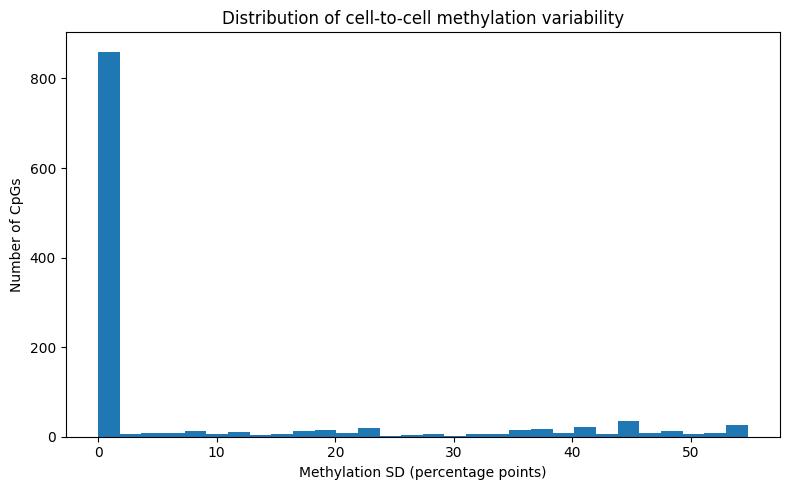

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(cpg_heterogeneity, bins=30)

plt.xlabel("Methylation SD (percentage points)")
plt.ylabel("Number of CpGs")
plt.title("Distribution of cell-to-cell methylation variability")

plt.tight_layout()
plt.show()

In [ ]:
# Categorize CpGs by observed methylation variability

bins = [-0.001, 1, 5, 10, 20, 30, 40, 50, 100]
labels = [
    "0–<1",
    "1–<5",
    "5–<10",
    "10–<20",
    "20–<30",
    "30–<40",
    "40–<50",
    "50+"
]

variability_categories = pd.cut(
    cpg_heterogeneity,
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

print(variability_categories.value_counts().sort_index())

0–<1      860
1–<5       10
5–<10      27
10–<20     51
20–<30     42
30–<40     53
40–<50     82
50+        41
Name: count, dtype: int64


In [ ]:
# Compare read depth with observed methylation variability

results = pd.DataFrame({
    "heterogeneity_sd": cpg_heterogeneity,
    "coverage_cells": matrix.notna().sum(axis=1)
})

print(results.groupby("coverage_cells")["heterogeneity_sd"].agg(
    ["count", "mean", "median", "max"]
))

                count       mean  median        max
coverage_cells                                     
5                 285   9.816734     0.0  54.772256
6                 217   8.996693     0.0  54.772256
7                 159  10.767812     0.0  53.452248
8                 170   8.249418     0.0  53.452248
9                 157   6.496512     0.0  44.096170
10                178   4.968320     0.0  45.845998


In [ ]:
high_coverage_matrix = matrix.loc[
    matrix.notna().sum(axis=1) >= 8
]

high_coverage_heterogeneity = high_coverage_matrix.std(
    axis=1,
    skipna=True
)

print("High-coverage CpGs:", len(high_coverage_heterogeneity))
print()
print(high_coverage_heterogeneity.describe())

High-coverage CpGs: 505

count    505.000000
mean       6.547949
std       12.923509
min        0.000000
25%        0.000000
50%        0.000000
75%        6.324555
max       53.452248
dtype: float64


In [ ]:
high_variability = high_coverage_heterogeneity[
    high_coverage_heterogeneity >= 10
]

print("High-coverage CpGs:", len(high_coverage_heterogeneity))
print("CpGs with SD >= 10:", len(high_variability))
print(
    "Percentage:",
    len(high_variability) / len(high_coverage_heterogeneity) * 100
)

High-coverage CpGs: 505
CpGs with SD >= 10: 108
Percentage: 21.386138613861387


In [ ]:
high_var_cpgs = high_coverage_heterogeneity[
    high_coverage_heterogeneity >= 10
].index

high_var_depths = []

for filename in files:
    with gzip.open(os.path.join(folder, filename), "rt") as f:
        for line in f:
            parts = line.strip().split("\t")
            chrom = parts[0]
            pos = int(parts[1])

            if (chrom, pos) in high_var_cpgs:
                high_var_depths.append(
                    int(parts[4]) + int(parts[5])
                )

high_var_depths = np.array(high_var_depths)

print("High-variability CpG observations:", len(high_var_depths))
print("Median depth:", np.median(high_var_depths))
print("Mean depth:", high_var_depths.mean())
print()

for d in [1, 2, 3, 5, 10]:
    n = (high_var_depths >= d).sum()
    print(f"Depth >= {d}: {n:,} ({n/len(high_var_depths)*100:.2f}%)")

High-variability CpG observations: 962
Median depth: 2.0
Mean depth: 2.601871101871102

Depth >= 1: 962 (100.00%)
Depth >= 2: 661 (68.71%)
Depth >= 3: 415 (43.14%)
Depth >= 5: 122 (12.68%)
Depth >= 10: 1 (0.10%)


In [ ]:

# Cell-level methylation heterogeneity
# Pairwise mean absolute difference between cells

cell_names = matrix.columns

cell_heterogeneity = pd.DataFrame(
    np.nan,
    index=cell_names,
    columns=cell_names
)

for cell_a in cell_names:
    for cell_b in cell_names:
        if cell_a == cell_b:
            cell_heterogeneity.loc[cell_a, cell_b] = 0
            continue

        paired = matrix[[cell_a, cell_b]].dropna()

        if len(paired) > 0:
            cell_heterogeneity.loc[cell_a, cell_b] = (
                paired[cell_a] - paired[cell_b]
            ).abs().mean()

# Average each cell's difference from all other cells
cell_profile = cell_heterogeneity.mean(axis=1).sort_values(
    ascending=False
)

print("Cell-level mean absolute methylation difference:")
print(cell_profile)

Cell-level mean absolute methylation difference:
GSM3436313_O8_TA_Hi_19    8.349421
GSM3436305_O8_TA_Hi_11    7.347641
GSM3436310_O8_TA_Hi_16    7.303013
GSM3436306_O8_TA_Hi_12    6.948043
GSM3436307_O8_TA_Hi_13    6.707941
GSM3436312_O8_TA_Hi_18    6.557348
GSM3436311_O8_TA_Hi_17    6.292170
GSM3436309_O8_TA_Hi_15    6.264769
GSM3436308_O8_TA_Hi_14    6.190436
GSM3436304_O8_TA_Hi_10    6.188793
dtype: float64


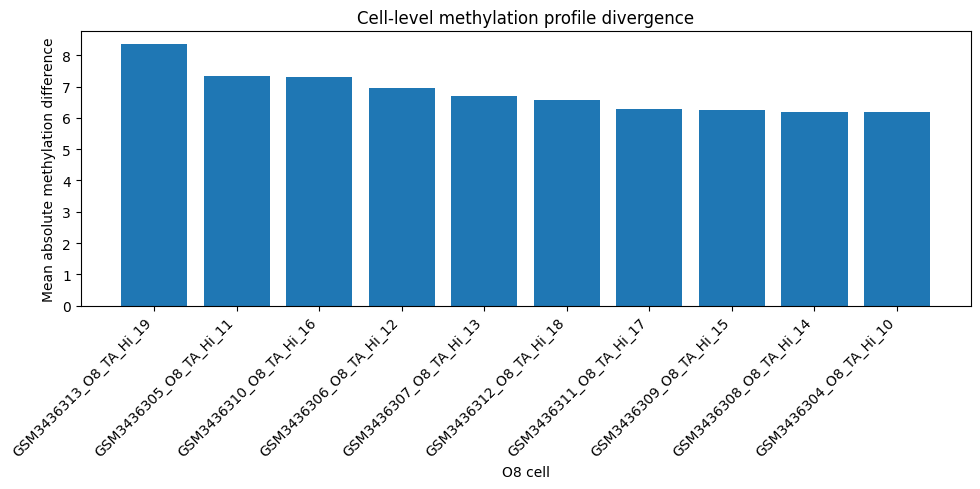

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    cell_profile.index,
    cell_profile.values
)

plt.ylabel("Mean absolute methylation difference")
plt.xlabel("O8 cell")
plt.title("Cell-level methylation profile divergence")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import os

os.makedirs("/content/methylation_data/Y2", exist_ok=True)

print("Y2 folder ready.")

Y2 folder ready.


In [ ]:
import os

y2_files = [
    ("GSM3436352_Y2_TA_Hi_10.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436352/suppl/GSM3436352_Y2_TA_Hi_10.cov.gz"),
    ("GSM3436353_Y2_TA_Hi_11.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436353/suppl/GSM3436353_Y2_TA_Hi_11.cov.gz"),
    ("GSM3436354_Y2_TA_Hi_12.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436354/suppl/GSM3436354_Y2_TA_Hi_12.cov.gz"),
    ("GSM3436355_Y2_TA_Hi_13.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436355/suppl/GSM3436355_Y2_TA_Hi_13.cov.gz"),
    ("GSM3436356_Y2_TA_Hi_14.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436356/suppl/GSM3436356_Y2_TA_Hi_14.cov.gz"),
    ("GSM3436357_Y2_TA_Hi_15.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436357/suppl/GSM3436357_Y2_TA_Hi_15.cov.gz"),
    ("GSM3436358_Y2_TA_Hi_17.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436358/suppl/GSM3436358_Y2_TA_Hi_17.cov.gz"),
    ("GSM3436359_Y2_TA_Hi_19.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436359/suppl/GSM3436359_Y2_TA_Hi_19.cov.gz"),
    ("GSM3436360_Y2_TA_Hi_1.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436360/suppl/GSM3436360_Y2_TA_Hi_1.cov.gz"),
    ("GSM3436361_Y2_TA_Hi_20.cov.gz", "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436361/suppl/GSM3436361_Y2_TA_Hi_20.cov.gz"),
]

for filename, url in y2_files:
    output = f"/content/methylation_data/Y2/{filename}"
    os.system(f'curl -L --retry 10 --retry-delay 2 "{url}" -o "{output}"')

print("Download commands completed.")

Download commands completed.


In [ ]:
import os
import gzip

y2_folder = "/content/methylation_data/Y2"

y2_files = sorted([
    f for f in os.listdir(y2_folder)
    if f.endswith(".cov.gz")
])

print("Number of Y2 files:", len(y2_files))
print()

for filename in y2_files:
    path = os.path.join(y2_folder, filename)

    try:
        with gzip.open(path, "rt") as f:
            first_line = f.readline().strip()

        size_mb = os.path.getsize(path) / (1024 * 1024)

        print(f"{filename}")
        print(f"  Size: {size_mb:.3f} MB")
        print(f"  GZIP: VALID")
        print(f"  First row: {first_line}")
        print()

    except Exception as e:
        print(f"{filename}")
        print(f"  ERROR: {e}")
        print()

Number of Y2 files: 10

GSM3436352_Y2_TA_Hi_10.cov.gz
  Size: 7.933 MB
  GZIP: VALID
  First row: 1	3048462	3048462	0.00	0	1

GSM3436353_Y2_TA_Hi_11.cov.gz
  Size: 7.470 MB
  GZIP: VALID
  First row: 1	3003227	3003227	100.00	1	0

GSM3436354_Y2_TA_Hi_12.cov.gz
  Size: 6.691 MB
  GZIP: VALID
  First row: 1	3001277	3001277	0.00	0	2

GSM3436355_Y2_TA_Hi_13.cov.gz
  Size: 6.082 MB
  GZIP: VALID
  First row: 1	3000827	3000827	100.00	1	0

GSM3436356_Y2_TA_Hi_14.cov.gz
  Size: 5.865 MB
  GZIP: VALID
  First row: 1	3003646	3003646	0.00	0	1

GSM3436357_Y2_TA_Hi_15.cov.gz
  Size: 5.674 MB
  GZIP: VALID
  First row: 1	3003339	3003339	100.00	1	0

GSM3436358_Y2_TA_Hi_17.cov.gz
  Size: 5.995 MB
  GZIP: VALID
  First row: 1	3020396	3020396	100.00	1	0

GSM3436359_Y2_TA_Hi_19.cov.gz
  Size: 6.027 MB
  GZIP: VALID
  First row: 1	3003899	3003899	100.00	1	0

GSM3436360_Y2_TA_Hi_1.cov.gz
  Size: 8.182 MB
  GZIP: VALID
  First row: 1	3003721	3003721	100.00	1	0

GSM3436361_Y2_TA_Hi_20.cov.gz
  Size: 6.987 MB


In [ ]:
import gzip
import os

y2_folder = "/content/methylation_data/Y2"

for filename in sorted(os.listdir(y2_folder)):
    if not filename.endswith(".cov.gz"):
        continue

    count = 0

    with gzip.open(os.path.join(y2_folder, filename), "rt") as f:
        for line in f:
            count += 1

    print(f"{filename}: {count:,} CpGs")

GSM3436352_Y2_TA_Hi_10.cov.gz: 1,511,609 CpGs
GSM3436353_Y2_TA_Hi_11.cov.gz: 1,401,291 CpGs
GSM3436354_Y2_TA_Hi_12.cov.gz: 1,260,616 CpGs
GSM3436355_Y2_TA_Hi_13.cov.gz: 1,136,838 CpGs
GSM3436356_Y2_TA_Hi_14.cov.gz: 1,099,475 CpGs
GSM3436357_Y2_TA_Hi_15.cov.gz: 1,064,311 CpGs
GSM3436358_Y2_TA_Hi_17.cov.gz: 1,141,987 CpGs
GSM3436359_Y2_TA_Hi_19.cov.gz: 1,133,524 CpGs
GSM3436360_Y2_TA_Hi_1.cov.gz: 1,578,521 CpGs
GSM3436361_Y2_TA_Hi_20.cov.gz: 1,327,998 CpGs


In [ ]:
import gzip
import os
from collections import Counter

y2_folder = "/content/methylation_data/Y2"

y2_files = sorted([
    f for f in os.listdir(y2_folder)
    if f.endswith(".cov.gz")
])

cpg_counts_y2 = Counter()

for filename in y2_files:
    with gzip.open(os.path.join(y2_folder, filename), "rt") as f:
        for line in f:
            chrom, pos = line.split("\t")[:2]
            cpg_counts_y2[(chrom, pos)] += 1

n = len(y2_files)

print("Total unique CpGs:", len(cpg_counts_y2))
print()

for threshold in [2, 3, 5, 7, 8, 9, 10]:
    retained = sum(v >= threshold for v in cpg_counts_y2.values())
    print(f"CpGs covered in >= {threshold}/{n} cells: {retained:,}")

Total unique CpGs: 9622730

CpGs covered in >= 2/10 cells: 2,300,202
CpGs covered in >= 3/10 cells: 541,013
CpGs covered in >= 5/10 cells: 33,251
CpGs covered in >= 7/10 cells: 7,760
CpGs covered in >= 8/10 cells: 5,469
CpGs covered in >= 9/10 cells: 3,960
CpGs covered in >= 10/10 cells: 2,787


In [ ]:
o8_high = {
    cpg for cpg, count in cpg_counts.items()
    if count >= 8
}

y2_high = {
    cpg for cpg, count in cpg_counts_y2.items()
    if count >= 8
}

common_cpgs = o8_high & y2_high

print("O8 CpGs (>=8/10):", len(o8_high))
print("Y2 CpGs (>=8/10):", len(y2_high))
print("Common CpGs:", len(common_cpgs))

O8 CpGs (>=8/10): 505
Y2 CpGs (>=8/10): 5469
Common CpGs: 0


In [ ]:
print("O8 example coordinates:")
print(list(o8_high)[:10])

print("\nY2 example coordinates:")
print(list(y2_high)[:10])

O8 example coordinates:
[('14', 35625935), ('8', 116221931), ('18', 47854191), ('1', 50173522), ('18', 68224329), ('15', 75910086), ('7', 6730280), ('12', 111101257), ('4', 57700495), ('11', 109498263)]

Y2 example coordinates:
[('17', '39846742'), ('11', '3156717'), ('6', '59129702'), ('10', '58239548'), ('4', '118548554'), ('14', '74124748'), ('8', '20514081'), ('11', '3134388'), ('5', '95927568'), ('4', '23095242')]


In [ ]:
y2_high_fixed = {
    (chrom, int(pos))
    for chrom, pos in y2_high
}

common_cpgs = o8_high & y2_high_fixed

print("O8 CpGs (>=8/10):", len(o8_high))
print("Y2 CpGs (>=8/10):", len(y2_high_fixed))
print("Common CpGs:", len(common_cpgs))

O8 CpGs (>=8/10): 505
Y2 CpGs (>=8/10): 5469
Common CpGs: 157


In [ ]:
common_cpgs = sorted(common_cpgs)

o8_common_matrix = matrix.loc[
    matrix.index.intersection(common_cpgs)
].sort_index()

y2_common_matrix = matrix_y2.loc[
    matrix_y2.index.intersection(common_cpgs)
].sort_index()

print("O8 common matrix:", o8_common_matrix.shape)
print("Y2 common matrix:", y2_common_matrix.shape)

NameError: name 'matrix_y2' is not defined

In [ ]:
import pandas as pd
import glob
import os

y2_files = glob.glob("/content/methylation_data/Y2/*.cov.gz")

y2_data = {}

for file in y2_files:
    cell_name = os.path.basename(file).replace(".cov.gz", "")

    df = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "methylation", "meth", "unmeth"],
        compression="gzip"
    )

    df["chrom"] = df["chrom"].astype(str)
    df["start"] = df["start"].astype(int)

    df["cpg"] = list(zip(df["chrom"], df["start"]))

    y2_data[cell_name] = df.set_index("cpg")["methylation"]

matrix_y2 = pd.DataFrame(y2_data)

# Keep only CpGs covered in >=8/10 Y2 cells
y2_common_matrix = matrix_y2.loc[
    matrix_y2.index.isin(common_cpgs)
].sort_index()

print("Y2 matrix:", matrix_y2.shape)
print("Y2 common matrix:", y2_common_matrix.shape)

/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_892/4271362020.py:12: DtypeWarning: Columns

Y2 matrix: (9622730, 10)
Y2 common matrix: (157, 10)


In [ ]:
print("O8 common matrix:", o8_common_matrix.shape)
print("Y2 common matrix:", y2_common_matrix.shape)

print("\nSame CpG coordinates:",
      o8_common_matrix.index.equals(y2_common_matrix.index))

O8 common matrix: (157, 10)
Y2 common matrix: (157, 10)

Same CpG coordinates: True


In [ ]:
o8_sd = o8_common_matrix.std(axis=1, skipna=True)
y2_sd = y2_common_matrix.std(axis=1, skipna=True)

print("O8 observed variability:")
print(o8_sd.describe())

print("\nY2 observed variability:")
print(y2_sd.describe())

O8 observed variability:
count    157.000000
mean       5.706606
std       11.162944
min        0.000000
25%        0.000000
50%        0.000000
75%        5.271517
max       53.452248
dtype: float64

Y2 observed variability:
count    157.000000
mean       9.428279
std       14.338857
min        0.000000
25%        0.000000
50%        0.000000
75%       16.666667
max       51.754917
dtype: float64


In [ ]:
comparison = pd.DataFrame({
    "O8_SD": o8_sd,
    "Y2_SD": y2_sd
})

comparison["Y2_minus_O8"] = comparison["Y2_SD"] - comparison["O8_SD"]

print("Y2 higher:", (comparison["Y2_minus_O8"] > 0).sum())
print("O8 higher:", (comparison["Y2_minus_O8"] < 0).sum())
print("Equal:", (comparison["Y2_minus_O8"] == 0).sum())

Y2 higher: 56
O8 higher: 21
Equal: 80


In [ ]:
diff = comparison["Y2_minus_O8"]

print("Mean Y2 - O8 SD:", diff.mean())
print("Median Y2 - O8 SD:", diff.median())
print("Minimum difference:", diff.min())
print("Maximum difference:", diff.max())

Mean Y2 - O8 SD: 3.721673153490301
Median Y2 - O8 SD: 0.0
Minimum difference: -25.333449342783126
Maximum difference: 44.44473959624219


In [ ]:
print("CpGs with |Y2 - O8| >= 10 pp:",
      (diff.abs() >= 10).sum())

print("CpGs with |Y2 - O8| >= 20 pp:",
      (diff.abs() >= 20).sum())

print("CpGs with |Y2 - O8| >= 30 pp:",
      (diff.abs() >= 30).sum())

CpGs with |Y2 - O8| >= 10 pp: 30
CpGs with |Y2 - O8| >= 20 pp: 11
CpGs with |Y2 - O8| >= 30 pp: 5


In [ ]:
print("O8 matched CpG depth:")
print(o8_common_matrix.notna().sum().describe())

print("\nY2 matched CpG depth:")
print(y2_common_matrix.notna().sum().describe())

O8 matched CpG depth:
count     10.000000
mean     149.000000
std       12.364825
min      118.000000
25%      154.000000
50%      154.000000
75%      154.750000
max      156.000000
dtype: float64

Y2 matched CpG depth:
count     10.000000
mean     145.100000
std       10.969149
min      122.000000
25%      141.000000
50%      148.000000
75%      153.500000
max      156.000000
dtype: float64


In [ ]:
print("O8 matrix shape:", o8_common_matrix.shape)
print("Y2 matrix shape:", y2_common_matrix.shape)

print("\nO8 non-missing values:")
print(o8_common_matrix.notna().sum(axis=1).describe())

print("\nY2 non-missing values:")
print(y2_common_matrix.notna().sum(axis=1).describe())

O8 matrix shape: (157, 10)
Y2 matrix shape: (157, 10)

O8 non-missing values:
count    157.000000
mean       9.490446
std        0.747799
min        8.000000
25%        9.000000
50%       10.000000
75%       10.000000
max       10.000000
dtype: float64

Y2 non-missing values:
count    157.000000
mean       9.242038
std        0.842777
min        8.000000
25%        8.000000
50%       10.000000
75%       10.000000
max       10.000000
dtype: float64


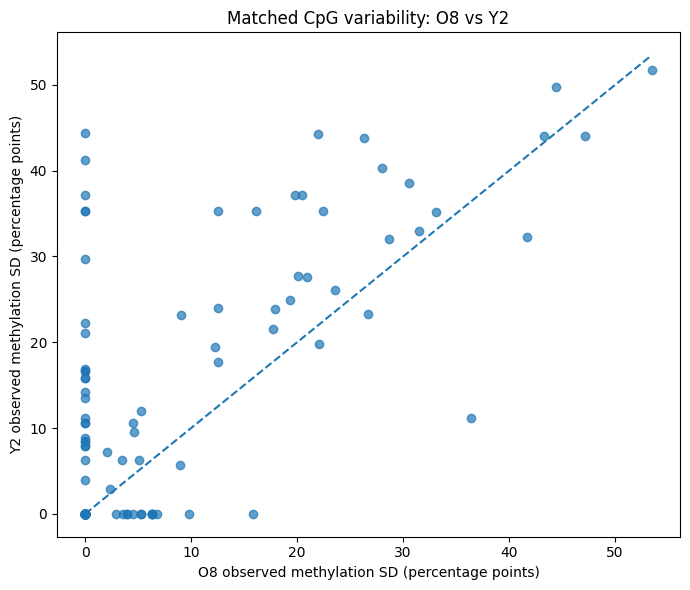

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    o8_sd,
    y2_sd,
    alpha=0.7
)

max_val = max(o8_sd.max(), y2_sd.max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--"
)

plt.xlabel("O8 observed methylation SD (percentage points)")
plt.ylabel("Y2 observed methylation SD (percentage points)")
plt.title("Matched CpG variability: O8 vs Y2")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(o8_sd, y2_sd)

print("Spearman rho:", rho)
print("P-value:", p)

Spearman rho: 0.59180149371123
P-value: 3.2948209918508247e-16


In [ ]:
import glob
import os

o1_files = glob.glob("/content/methylation_data/**/*O1*.cov.gz", recursive=True)

print("O1 files found:", len(o1_files))

for f in sorted(o1_files)[:20]:
    print(os.path.basename(f))

O1 files found: 2
GSM3436261_O1_TA_Hi_10.cov.gz
GSM3436262_O1_TA_Hi_11.cov.gz


In [ ]:
import os

os.makedirs("/content/methylation_data/O1", exist_ok=True)

In [ ]:
import os

os.makedirs("/content/methylation_data/O1", exist_ok=True)

o1_urls = [
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436263/suppl/GSM3436263_O1_TA_Hi_12.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436264/suppl/GSM3436264_O1_TA_Hi_13.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436265/suppl/GSM3436265_O1_TA_Hi_14.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436266/suppl/GSM3436266_O1_TA_Hi_15.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436267/suppl/GSM3436267_O1_TA_Hi_16.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436268/suppl/GSM3436268_O1_TA_Hi_17.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436269/suppl/GSM3436269_O1_TA_Hi_18.cov.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436270/suppl/GSM3436270_O1_TA_Hi_19.cov.gz",
]

for url in o1_urls:
    filename = url.split("/")[-1]
    output = f"/content/methylation_data/O1/{filename}"

    print("Downloading:", filename)

    !curl -L --retry 10 --retry-delay 2 "{url}" -o "{output}"

print("\nDone.")

Downloading: GSM3436263_O1_TA_Hi_12.cov.gz
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 8300k    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
curl: (18) transfer closed with 8499959 bytes remaining to read
Downloading: GSM3436264_O1_TA_Hi_13.cov.gz
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 10.0M  100 10.0M    0     0  43.5M      0 --:--:-- --:--:-- --:--:-- 43.6M
Downloading: GSM3436265_O1_TA_Hi_14.cov.gz
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7932k  100 7932k    0     0  38.8M      0 --:--:-- --:--:-- --:--:-- 38.9M
Downloading: GSM3436266_O1_TA_Hi_15.cov.gz
  % Total    % Received % Xferd  Average Speed   Time

In [ ]:
import glob
import os
import gzip

o1_files = sorted(glob.glob("/content/methylation_data/O1/*.cov.gz"))

print("O1 files:", len(o1_files))

for f in o1_files:
    size_mb = os.path.getsize(f) / (1024**2)

    try:
        with gzip.open(f, "rt") as fh:
            first_line = fh.readline().strip()
        status = "VALID GZIP"
    except Exception as e:
        first_line = ""
        status = f"BAD GZIP: {e}"

    print(f"{os.path.basename(f):45s} {size_mb:7.2f} MB  {status}")
    print("   ", first_line)

O1 files: 7
GSM3436264_O1_TA_Hi_13.cov.gz                   10.04 MB  VALID GZIP
    1	3015984	3015984	0.00	0	1
GSM3436265_O1_TA_Hi_14.cov.gz                    7.75 MB  VALID GZIP
    1	3003380	3003380	100.00	1	0
GSM3436266_O1_TA_Hi_15.cov.gz                   10.21 MB  VALID GZIP
    1	3003885	3003885	100.00	4	0
GSM3436267_O1_TA_Hi_16.cov.gz                    9.67 MB  VALID GZIP
    1	3003582	3003582	100.00	1	0
GSM3436268_O1_TA_Hi_17.cov.gz                   10.95 MB  VALID GZIP
    1	3020396	3020396	100.00	1	0
GSM3436269_O1_TA_Hi_18.cov.gz                    0.16 MB  VALID GZIP
    1	3053897	3053897	100.00	1	0
GSM3436270_O1_TA_Hi_19.cov.gz                    9.92 MB  VALID GZIP
    1	3003721	3003721	0.00	0	1


In [ ]:
!curl -L --retry 20 --retry-delay 3 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436263/suppl/GSM3436263_O1_TA_Hi_12.cov.gz" \
-o "/content/methylation_data/O1/GSM3436263_O1_TA_Hi_12.cov.gz"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 8300k    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
curl: (18) transfer closed with 8499959 bytes remaining to read


In [ ]:
!curl -L -C - --retry 20 --retry-delay 3 \
"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436263/suppl/GSM3436263_O1_TA_Hi_12.cov.gz" \
-o "/content/methylation_data/O1/GSM3436263_O1_TA_Hi_12.cov.gz"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 8300k    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
curl: (18) transfer closed with 8499959 bytes remaining to read


In [ ]:
import glob
import os

all_o1 = glob.glob("/content/methylation_data/**/*O1*.cov.gz", recursive=True)

print("Total O1 files:", len(all_o1))

for f in sorted(all_o1):
    print(os.path.relpath(f, "/content/methylation_data"))

Total O1 files: 9
GSM3436261_O1_TA_Hi_10.cov.gz
GSM3436262_O1_TA_Hi_11.cov.gz
O1/GSM3436264_O1_TA_Hi_13.cov.gz
O1/GSM3436265_O1_TA_Hi_14.cov.gz
O1/GSM3436266_O1_TA_Hi_15.cov.gz
O1/GSM3436267_O1_TA_Hi_16.cov.gz
O1/GSM3436268_O1_TA_Hi_17.cov.gz
O1/GSM3436269_O1_TA_Hi_18.cov.gz
O1/GSM3436270_O1_TA_Hi_19.cov.gz


In [ ]:
import pandas as pd
from collections import Counter
import glob
import os

o1_files = sorted(
    glob.glob("/content/methylation_data/**/*O1*.cov.gz", recursive=True)
)

o1_cpg_counts = Counter()

for file in o1_files:
    df = pd.read_csv(
        file,
        sep="\t",
        header=None,
        usecols=[0, 1],
        names=["chrom", "pos"],
        dtype={"chrom": str, "pos": "int64"},
        compression="gzip"
    )

    cpgs = set(zip(df["chrom"], df["pos"]))

    for cpg in cpgs:
        o1_cpg_counts[cpg] += 1

print("O1 cells:", len(o1_files))
print("Total unique O1 CpGs:", len(o1_cpg_counts))
print("CpGs covered in >=8/9 cells:",
      sum(n >= 8 for n in o1_cpg_counts.values()))

O1 cells: 9
Total unique O1 CpGs: 9524050
CpGs covered in >=8/9 cells: 491


In [ ]:
import pandas as pd
import glob
import os

o1_files = sorted(
    glob.glob("/content/methylation_data/**/*O1*.cov.gz", recursive=True)
)

o1_data = {}

for file in o1_files:
    cell_name = os.path.basename(file).replace(".cov.gz", "")

    df = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "methylation", "meth", "unmeth"],
        compression="gzip"
    )

    df["chrom"] = df["chrom"].astype(str)
    df["start"] = df["start"].astype(int)

    df["cpg"] = list(zip(df["chrom"], df["start"]))

    o1_data[cell_name] = df.set_index("cpg")["methylation"]

matrix_o1 = pd.DataFrame(o1_data)

# Recreate the coverage counts
o1_cpg_counts = {}

for file in o1_files:
    df = pd.read_csv(
        file,
        sep="\t",
        header=None,
        usecols=[0, 1],
        names=["chrom", "pos"],
        dtype={"chrom": str, "pos": "int64"},
        compression="gzip"
    )

    for cpg in set(zip(df["chrom"], df["pos"])):
        o1_cpg_counts[cpg] = o1_cpg_counts.get(cpg, 0) + 1

o1_high = [
    cpg for cpg, count in o1_cpg_counts.items()
    if count >= 8
]

o1_common_matrix = matrix_o1.loc[
    matrix_o1.index.isin(o1_high)
].sort_index()

print("O1 files:", len(o1_files))
print("O1 matrix:", matrix_o1.shape)
print("O1 high-coverage matrix:", o1_common_matrix.shape)

/tmp/ipykernel_14143/1750127571.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/1750127571.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/1750127571.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/1750127571.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/1750127571.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/1750127571.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/1750127571.py:14: DtypeWa

O1 files: 9
O1 matrix: (9524050, 9)
O1 high-coverage matrix: (491, 9)


In [ ]:
del matrix_o1
del o1_data

import gc
gc.collect()

print("Cleared full O1 matrix from RAM.")

Cleared full O1 matrix from RAM.


In [ ]:
o1_small = {}

for file in o1_files:
    cell_name = os.path.basename(file).replace(".cov.gz", "")

    df = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "methylation", "meth", "unmeth"],
        compression="gzip"
    )

    df["chrom"] = df["chrom"].astype(str)
    df["start"] = df["start"].astype(int)

    df["cpg"] = list(zip(df["chrom"], df["start"]))

    # Keep only the 491 high-coverage CpGs
    df = df[df["cpg"].isin(o1_high)]

    o1_small[cell_name] = df.set_index("cpg")["methylation"]

o1_common_matrix = pd.DataFrame(o1_small).sort_index()

print("O1 reduced matrix:", o1_common_matrix.shape)

/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_14143/3751656514.py:6: DtypeWarning: 

O1 reduced matrix: (491, 9)


In [ ]:
o1_sd = o1_common_matrix.std(axis=1, skipna=True)

print("O1 observed variability:")
print(o1_sd.describe())

O1 observed variability:
count     491.0
unique    397.0
top         0.0
freq       73.0
dtype: float64


In [ ]:
o1_common_matrix = o1_common_matrix.apply(
    pd.to_numeric,
    errors="coerce"
)

o1_sd = o1_common_matrix.std(axis=1, skipna=True)

print("O1 observed variability:")
print(o1_sd.describe())

O1 observed variability:
count    491.000000
mean      15.936967
std       12.186196
min        0.000000
25%        7.232544
50%       13.619177
75%       23.200247
max       53.452248
dtype: float64


In [ ]:
o1_high = {
    cpg for cpg, count in o1_cpg_counts.items()
    if count >= 8
}

o8_high = {
    cpg for cpg, count in o8_cpg_counts.items()
    if count >= 8
}

o1_o8_common = o1_high & o8_high

print("O1 CpGs (>=8/9):", len(o1_high))
print("O8 CpGs (>=8/10):", len(o8_high))
print("Common O1-O8 CpGs:", len(o1_o8_common))

In [ ]:
import glob
from collections import defaultdict
import gzip

o8_files = sorted(glob.glob("/content/methylation_data/**/*O8*.cov.gz", recursive=True))

o8_cpg_counts = defaultdict(int)

for f in o8_files:
    seen = set()

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            chrom = parts[0]
            pos = int(parts[1])
            seen.add((chrom, pos))

    for cpg in seen:
        o8_cpg_counts[cpg] += 1

print("O8 files:", len(o8_files))
print("O8 unique CpGs:", len(o8_cpg_counts))
print("O8 CpGs covered in >=8/10:", sum(v >= 8 for v in o8_cpg_counts.values()))

O8 files: 10
O8 unique CpGs: 1946544
O8 CpGs covered in >=8/10: 505


In [ ]:
o1_high = {
    cpg for cpg, count in o1_cpg_counts.items()
    if count >= 8
}

o8_high = {
    cpg for cpg, count in o8_cpg_counts.items()
    if count >= 8
}

o1_o8_common = o1_high.intersection(o8_high)

print("O1 CpGs (>=8/9):", len(o1_high))
print("O8 CpGs (>=8/10):", len(o8_high))
print("Common O1-O8 CpGs:", len(o1_o8_common))

O1 CpGs (>=8/9): 491
O8 CpGs (>=8/10): 505
Common O1-O8 CpGs: 104


In [ ]:
# Build O1 matrix only for the 104 shared CpGs

import pandas as pd
import numpy as np
import gzip

o1_o8_common = set(o1_o8_common)

o1_common_matrix = pd.DataFrame(
    index=pd.MultiIndex.from_tuples(
        sorted(o1_o8_common),
        names=["chrom", "position"]
    )
)

for f in o1_files:
    cell = f.split("/")[-1].replace(".cov.gz", "")

    values = {}

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            chrom = parts[0]
            pos = int(parts[1])
            cpg = (chrom, pos)

            if cpg in o1_o8_common:
                values[cpg] = float(parts[3])

    o1_common_matrix[cell] = pd.Series(values)

o1_common_matrix = o1_common_matrix.apply(pd.to_numeric, errors="coerce")

print("O1 matched matrix shape:", o1_common_matrix.shape)
print("\nNon-missing observations per CpG:")
print(o1_common_matrix.notna().sum(axis=1).value_counts().sort_index())

O1 matched matrix shape: (104, 9)

Non-missing observations per CpG:
8    104
Name: count, dtype: int64


In [ ]:
# Build O8 matrix for the same 104 CpGs

o8_common_matrix = pd.DataFrame(
    index=pd.MultiIndex.from_tuples(
        sorted(o1_o8_common),
        names=["chrom", "position"]
    )
)

for f in o8_files:
    cell = f.split("/")[-1].replace(".cov.gz", "")

    values = {}

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            chrom = parts[0]
            pos = int(parts[1])
            cpg = (chrom, pos)

            if cpg in o1_o8_common:
                values[cpg] = float(parts[3])

    o8_common_matrix[cell] = pd.Series(values)

o8_common_matrix = o8_common_matrix.apply(pd.to_numeric, errors="coerce")

print("O8 matched matrix shape:", o8_common_matrix.shape)
print("\nNon-missing observations per CpG:")
print(o8_common_matrix.notna().sum(axis=1).value_counts().sort_index())

O8 matched matrix shape: (104, 10)

Non-missing observations per CpG:
8      3
9     20
10    81
Name: count, dtype: int64


In [ ]:
o1_sd = o1_common_matrix.std(axis=1, skipna=True)
o8_sd = o8_common_matrix.std(axis=1, skipna=True)

comparison = pd.DataFrame({
    "O1_SD": o1_sd,
    "O8_SD": o8_sd,
    "Difference_O8_minus_O1": o8_sd - o1_sd
})

print("O1 variability:")
print(o1_sd.describe())

print("\nO8 variability:")
print(o8_sd.describe())

print("\nMean O8 - O1 SD:",
      comparison["Difference_O8_minus_O1"].mean())

print("Median O8 - O1 SD:",
      comparison["Difference_O8_minus_O1"].median())

print("\nDirection:")
print("O8 higher:", (comparison["Difference_O8_minus_O1"] > 0).sum())
print("O1 higher:", (comparison["Difference_O8_minus_O1"] < 0).sum())
print("Equal:", (comparison["Difference_O8_minus_O1"] == 0).sum())

O1 variability:
count    104.000000
mean       7.057888
std       13.038093
min        0.000000
25%        0.000000
50%        0.000000
75%        6.363611
max       53.452248
dtype: float64

O8 variability:
count    104.000000
mean       5.183228
std        9.429097
min        0.000000
25%        0.000000
50%        0.000000
75%        5.534776
max       47.140789
dtype: float64

Mean O8 - O1 SD: -1.8746601241004666
Median O8 - O1 SD: 0.0

Direction:
O8 higher: 20
O1 higher: 31
Equal: 53


In [ ]:

def get_depth_matrix(files, target_cpgs):
    depth_matrix = pd.DataFrame(
        index=pd.MultiIndex.from_tuples(
            sorted(target_cpgs),
            names=["chrom", "position"]
        )
    )

    for f in files:
        cell = f.split("/")[-1].replace(".cov.gz", "")
        values = {}

        with gzip.open(f, "rt") as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) < 6:
                    continue

                cpg = (parts[0], int(parts[1]))

                if cpg in target_cpgs:
                    methylated = int(parts[4])
                    unmethylated = int(parts[5])
                    values[cpg] = methylated + unmethylated

        depth_matrix[cell] = pd.Series(values)

    return depth_matrix.apply(pd.to_numeric, errors="coerce")


o1_depth_common = get_depth_matrix(o1_files, o1_o8_common)
o8_depth_common = get_depth_matrix(o8_files, o1_o8_common)

combined_depth = pd.concat([
    o1_depth_common.stack(),
    o8_depth_common.stack()
])

print("Combined read-depth summary:")
print(combined_depth.describe())

print("\nDepth >=2:", (combined_depth >= 2).mean() * 100, "%")
print("Depth >=3:", (combined_depth >= 3).mean() * 100, "%")
print("Depth >=5:", (combined_depth >= 5).mean() * 100, "%")
print("Depth >=10:", (combined_depth >= 10).mean() * 100, "%")

Combined read-depth summary:
count    1846.000000
mean        5.270856
std         4.171823
min         1.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        29.000000
dtype: float64

Depth >=2: 89.27410617551462 %
Depth >=3: 73.56446370530878 %
Depth >=5: 45.882990249187436 %
Depth >=10: 12.56771397616468 %


In [ ]:
# Average read depth for each shared CpG
o1_mean_depth = o1_depth_common.mean(axis=1, skipna=True)
o8_mean_depth = o8_depth_common.mean(axis=1, skipna=True)

qc_variability = pd.DataFrame({
    "O1_SD": o1_sd,
    "O8_SD": o8_sd,
    "O1_mean_depth": o1_mean_depth,
    "O8_mean_depth": o8_mean_depth
})

qc_variability["mean_depth"] = qc_variability[
    ["O1_mean_depth", "O8_mean_depth"]
].mean(axis=1)

qc_variability["mean_SD"] = qc_variability[
    ["O1_SD", "O8_SD"]
].mean(axis=1)

print(qc_variability[["mean_SD", "mean_depth"]].corr(method="spearman"))

             mean_SD  mean_depth
mean_SD     1.000000   -0.099624
mean_depth -0.099624    1.000000


In [ ]:
import glob
import gzip
from collections import defaultdict

y2_files = sorted(
    glob.glob("/content/methylation_data/Y2/*.cov.gz")
)

y2_cpg_counts = defaultdict(int)

for f in y2_files:
    seen = set()

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            seen.add((parts[0], int(parts[1])))

    for cpg in seen:
        y2_cpg_counts[cpg] += 1

print("Y2 files:", len(y2_files))
print("Y2 unique CpGs:", len(y2_cpg_counts))
print("Y2 CpGs covered in >=8/10:",
      sum(v >= 8 for v in y2_cpg_counts.values()))

Y2 files: 10
Y2 unique CpGs: 9622730
Y2 CpGs covered in >=8/10: 5469


In [ ]:
y2_high = {
    cpg for cpg, count in y2_cpg_counts.items()
    if count >= 8
}

o1_o8_y2_common = o1_high & o8_high & y2_high

print("O1 high-coverage CpGs:", len(o1_high))
print("O8 high-coverage CpGs:", len(o8_high))
print("Y2 high-coverage CpGs:", len(y2_high))
print("Common O1-O8-Y2 CpGs:", len(o1_o8_y2_common))

O1 high-coverage CpGs: 491
O8 high-coverage CpGs: 505
Y2 high-coverage CpGs: 5469
Common O1-O8-Y2 CpGs: 83


In [ ]:
o1_youngold_common = o1_o8_y2_common

o1_y2_matrix = pd.DataFrame(
    index=pd.MultiIndex.from_tuples(
        sorted(o1_youngold_common),
        names=["chrom", "position"]
    )
)

for f in o1_files:
    cell = f.split("/")[-1].replace(".cov.gz", "")
    values = {}

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            cpg = (parts[0], int(parts[1]))

            if cpg in o1_youngold_common:
                values[cpg] = float(parts[3])

    o1_y2_matrix[cell] = pd.Series(values)

o1_y2_matrix = o1_y2_matrix.apply(pd.to_numeric, errors="coerce")

print("O1 matched matrix:", o1_y2_matrix.shape)
print("\nCoverage per CpG:")
print(o1_y2_matrix.notna().sum(axis=1).value_counts().sort_index())

O1 matched matrix: (83, 9)

Coverage per CpG:
8    83
Name: count, dtype: int64


In [ ]:
o8_y2_matrix = pd.DataFrame(
    index=pd.MultiIndex.from_tuples(
        sorted(o1_youngold_common),
        names=["chrom", "position"]
    )
)

for f in o8_files:
    cell = f.split("/")[-1].replace(".cov.gz", "")
    values = {}

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            cpg = (parts[0], int(parts[1]))

            if cpg in o1_youngold_common:
                values[cpg] = float(parts[3])

    o8_y2_matrix[cell] = pd.Series(values)

o8_y2_matrix = o8_y2_matrix.apply(pd.to_numeric, errors="coerce")

print("O8 matched matrix:", o8_y2_matrix.shape)
print("\nCoverage per CpG:")
print(o8_y2_matrix.notna().sum(axis=1).value_counts().sort_index())

O8 matched matrix: (83, 10)

Coverage per CpG:
8      3
9      9
10    71
Name: count, dtype: int64


In [ ]:
y2_youngold_matrix = pd.DataFrame(
    index=pd.MultiIndex.from_tuples(
        sorted(o1_youngold_common),
        names=["chrom", "position"]
    )
)

for f in y2_files:
    cell = f.split("/")[-1].replace(".cov.gz", "")
    values = {}

    with gzip.open(f, "rt") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 6:
                continue

            cpg = (parts[0], int(parts[1]))

            if cpg in o1_youngold_common:
                values[cpg] = float(parts[3])

    y2_youngold_matrix[cell] = pd.Series(values)

y2_youngold_matrix = y2_youngold_matrix.apply(pd.to_numeric, errors="coerce")

print("Y2 matched matrix:", y2_youngold_matrix.shape)
print("\nCoverage per CpG:")
print(y2_youngold_matrix.notna().sum(axis=1).value_counts().sort_index())

Y2 matched matrix: (83, 10)

Coverage per CpG:
8      8
9     12
10    63
Name: count, dtype: int64


In [ ]:
o1_y2_sd = o1_y2_matrix.std(axis=1, skipna=True)
o8_y2_sd = o8_y2_matrix.std(axis=1, skipna=True)
y2_sd = y2_youngold_matrix.std(axis=1, skipna=True)

three_sample_comparison = pd.DataFrame({
    "O1_old_SD": o1_y2_sd,
    "O8_old_SD": o8_y2_sd,
    "Y2_young_SD": y2_sd
})

print("O1 (old) variability:")
print(o1_y2_sd.describe())

print("\nO8 (old) variability:")
print(o8_y2_sd.describe())

print("\nY2 (young) variability:")
print(y2_sd.describe())

print("\nMean observed SD:")
print(three_sample_comparison.mean())

print("\nMedian observed SD:")
print(three_sample_comparison.median())

O1 (old) variability:
count    83.000000
mean      6.847954
std      12.924892
min       0.000000
25%       0.000000
50%       0.000000
75%       6.099423
max      53.452248
dtype: float64

O8 (old) variability:
count    83.000000
mean      5.157270
std       9.616149
min       0.000000
25%       0.000000
50%       0.000000
75%       5.271517
max      47.140789
dtype: float64

Y2 (young) variability:
count    83.000000
mean      8.164172
std      12.385722
min       0.000000
25%       0.000000
50%       0.000000
75%      14.682455
max      49.721446
dtype: float64

Mean observed SD:
O1_old_SD      6.847954
O8_old_SD      5.157270
Y2_young_SD    8.164172
dtype: float64

Median observed SD:
O1_old_SD      0.0
O8_old_SD      0.0
Y2_young_SD    0.0
dtype: float64


In [ ]:
y2_vs_both = (
    (y2_sd > o1_y2_sd) &
    (y2_sd > o8_y2_sd)
)

o1_vs_y2 = (
    (o1_y2_sd > y2_sd)
)

o8_vs_y2 = (
    (o8_y2_sd > y2_sd)
)

print("Y2 higher than BOTH O1 and O8:", y2_vs_both.sum())
print("O1 higher than Y2:", o1_vs_y2.sum())
print("O8 higher than Y2:", o8_vs_y2.sum())

Y2 higher than BOTH O1 and O8: 28
O1 higher than Y2: 14
O8 higher than Y2: 14


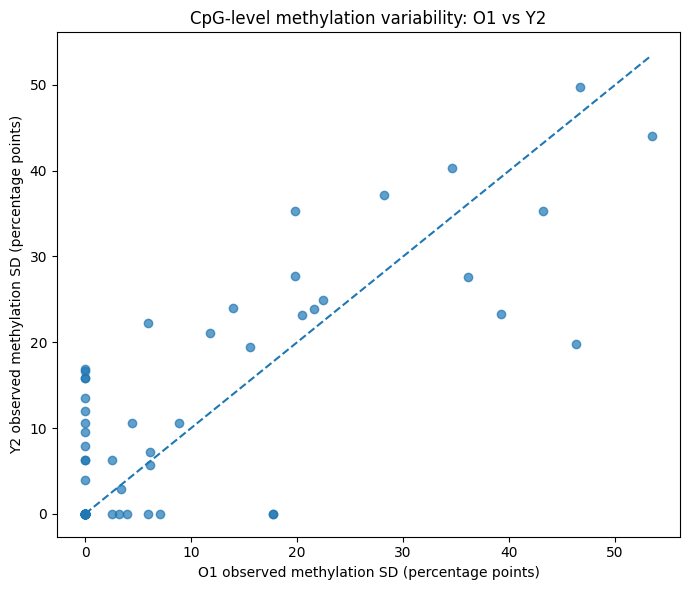

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(o1_y2_sd, y2_sd, alpha=0.7)

max_val = max(o1_y2_sd.max(), y2_sd.max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("O1 observed methylation SD (percentage points)")
plt.ylabel("Y2 observed methylation SD (percentage points)")
plt.title("CpG-level methylation variability: O1 vs Y2")

plt.tight_layout()
plt.show()

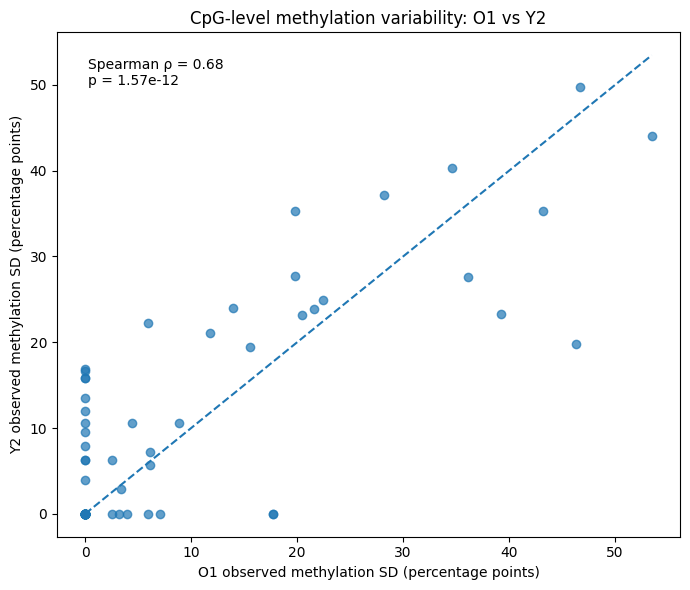

Spearman rho: 0.6799011455013214
p-value: 1.5704251384481653e-12


In [ ]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

rho, p = spearmanr(o1_y2_sd, y2_sd)

plt.figure(figsize=(7, 6))

plt.scatter(o1_y2_sd, y2_sd, alpha=0.7)

max_val = max(o1_y2_sd.max(), y2_sd.max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("O1 observed methylation SD (percentage points)")
plt.ylabel("Y2 observed methylation SD (percentage points)")
plt.title("CpG-level methylation variability: O1 vs Y2")

plt.text(
    0.05, 0.95,
    f"Spearman ρ = {rho:.2f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

print("Spearman rho:", rho)
print("p-value:", p)

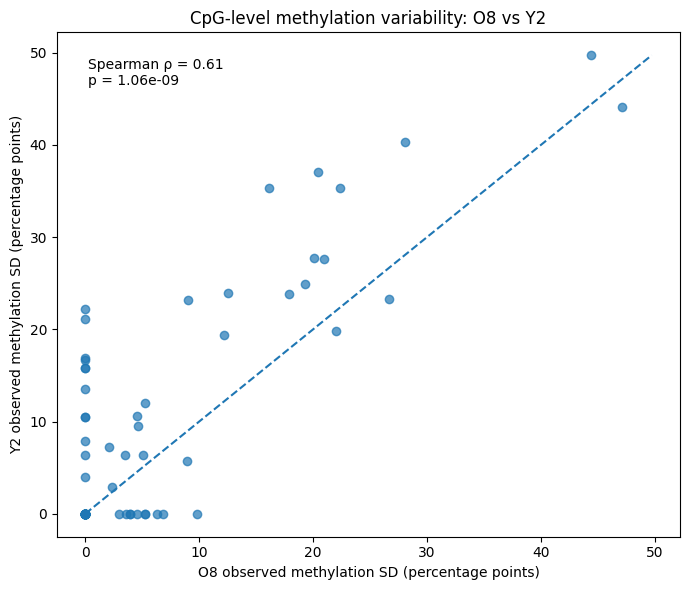

Spearman rho: 0.6082807521024944
p-value: 1.0638728981482169e-09


In [ ]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

rho_o8, p_o8 = spearmanr(o8_y2_sd, y2_sd)

plt.figure(figsize=(7, 6))

plt.scatter(o8_y2_sd, y2_sd, alpha=0.7)

max_val = max(o8_y2_sd.max(), y2_sd.max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("O8 observed methylation SD (percentage points)")
plt.ylabel("Y2 observed methylation SD (percentage points)")
plt.title("CpG-level methylation variability: O8 vs Y2")

plt.text(
    0.05, 0.95,
    f"Spearman ρ = {rho_o8:.2f}\np = {p_o8:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

print("Spearman rho:", rho_o8)
print("p-value:", p_o8)

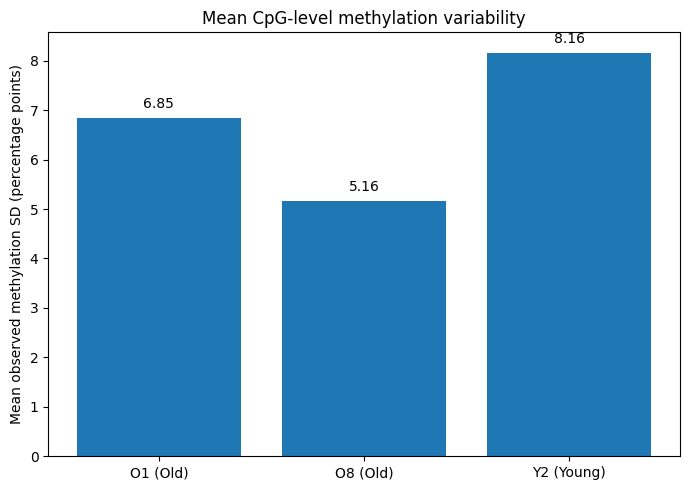

In [ ]:
import matplotlib.pyplot as plt

samples = ["O1 (Old)", "O8 (Old)", "Y2 (Young)"]
mean_sd = [
    o1_y2_sd.mean(),
    o8_y2_sd.mean(),
    y2_sd.mean()
]

plt.figure(figsize=(7, 5))

plt.bar(samples, mean_sd)

plt.ylabel("Mean observed methylation SD (percentage points)")
plt.title("Mean CpG-level methylation variability")

for i, value in enumerate(mean_sd):
    plt.text(i, value + 0.2, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

## O1 vs O8: Matched High-Coverage CpGs

To compare methylation variability between the two old-mouse samples, CpGs were restricted to loci covered in at least 8 cells in each sample.

O1 contained 491 high-coverage CpGs and O8 contained 505. Their intersection contained 104 shared CpGs.

Variability at each shared CpG was quantified as the standard deviation of observed methylation percentages across cells, while missing observations were retained as missing values.

Because O1 and O8 represent individual mice rather than independent biological replicates of an age group, this comparison is descriptive and is not treated as an inferential test of aging.

In [ ]:
import os

os.makedirs("/content/methylation_data", exist_ok=True)

print("Folder created:", os.path.exists("/content/methylation_data"))

Folder created: True


In [ ]:
import os

os.makedirs("/content/methylation_data/O1", exist_ok=True)

base = "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM34362"

files = {
    "10": "61/GSM3436261_O1_TA_Hi_10.cov.gz",
    "11": "62/GSM3436262_O1_TA_Hi_11.cov.gz",
    "13": "64/GSM3436264_O1_TA_Hi_13.cov.gz",
    "14": "65/GSM3436265_O1_TA_Hi_14.cov.gz",
    "15": "66/GSM3436266_O1_TA_Hi_15.cov.gz",
    "16": "67/GSM3436267_O1_TA_Hi_16.cov.gz",
    "17": "68/GSM3436268_O1_TA_Hi_17.cov.gz",
    "18": "69/GSM3436269_O1_TA_Hi_18.cov.gz",
    "19": "70/GSM3436270_O1_TA_Hi_19.cov.gz"
}

for cell, path in files.items():
    url = f"{base}{path}"
    out = f"/content/methylation_data/O1/GSM343626{int(cell):02d}_O1_TA_Hi_{cell}.cov.gz"
    print(f"Downloading O1_Hi_{cell}...")
    os.system(f'curl -L --retry 5 --retry-delay 2 "{url}" -o "{out}" -sS')

print("\nFiles downloaded:", len(os.listdir("/content/methylation_data/O1")))


Files downloaded: 9


In [ ]:
import glob
import gzip

o1_files = sorted(
    glob.glob("/content/methylation_data/O1/*.cov.gz")
)

print("O1 files:", len(o1_files))

for f in o1_files:
    with gzip.open(f, "rt") as gz:
        first_line = gz.readline().strip()
    print(os.path.basename(f), "→", first_line)

O1 files: 9


BadGzipFile: Not a gzipped file (b'<?')

In [ ]:
import glob
import gzip
import os

o1_files = sorted(glob.glob("/content/methylation_data/O1/*.cov.gz"))

for f in o1_files:
    try:
        with gzip.open(f, "rt") as gz:
            line = gz.readline().strip()
        print("GOOD:", os.path.basename(f), "→", line[:50])
    except Exception as e:
        print("BAD: ", os.path.basename(f), "→", type(e).__name__)

BAD:  GSM34362610_O1_TA_Hi_10.cov.gz → BadGzipFile
BAD:  GSM34362611_O1_TA_Hi_11.cov.gz → BadGzipFile
BAD:  GSM34362613_O1_TA_Hi_13.cov.gz → BadGzipFile
BAD:  GSM34362614_O1_TA_Hi_14.cov.gz → BadGzipFile
BAD:  GSM34362615_O1_TA_Hi_15.cov.gz → BadGzipFile
BAD:  GSM34362616_O1_TA_Hi_16.cov.gz → BadGzipFile
BAD:  GSM34362617_O1_TA_Hi_17.cov.gz → BadGzipFile
BAD:  GSM34362618_O1_TA_Hi_18.cov.gz → BadGzipFile
BAD:  GSM34362619_O1_TA_Hi_19.cov.gz → BadGzipFile


In [ ]:
import os
import glob

for f in glob.glob("/content/methylation_data/O1/*.cov.gz"):
    os.remove(f)

print("Remaining O1 files:", len(glob.glob("/content/methylation_data/O1/*.cov.gz")))

Remaining O1 files: 0


In [ ]:
import os

os.makedirs("/content/methylation_data/O1", exist_ok=True)

o1_urls = {
    "GSM3436261_O1_TA_Hi_10.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436261/suppl/GSM3436261_O1_TA_Hi_10.cov.gz",

    "GSM3436262_O1_TA_Hi_11.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436262/suppl/GSM3436262_O1_TA_Hi_11.cov.gz",

    "GSM3436264_O1_TA_Hi_13.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436264/suppl/GSM3436264_O1_TA_Hi_13.cov.gz",

    "GSM3436265_O1_TA_Hi_14.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436265/suppl/GSM3436265_O1_TA_Hi_14.cov.gz",

    "GSM3436266_O1_TA_Hi_15.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436266/suppl/GSM3436266_O1_TA_Hi_15.cov.gz",

    "GSM3436267_O1_TA_Hi_16.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436267/suppl/GSM3436267_O1_TA_Hi_16.cov.gz",

    "GSM3436268_O1_TA_Hi_17.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436268/suppl/GSM3436268_O1_TA_Hi_17.cov.gz",

    "GSM3436269_O1_TA_Hi_18.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436269/suppl/GSM3436269_O1_TA_Hi_18.cov.gz",

    "GSM3436270_O1_TA_Hi_19.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436270/suppl/GSM3436270_O1_TA_Hi_19.cov.gz"
}

for filename, url in o1_urls.items():
    output = f"/content/methylation_data/O1/{filename}"
    print("Downloading:", filename)
    os.system(f'curl -L --retry 5 --retry-delay 2 "{url}" -o "{output}" -sS')

print("\nDownloaded files:",
      len(os.listdir("/content/methylation_data/O1")))

Downloading: GSM3436261_O1_TA_Hi_10.cov.gz
Downloading: GSM3436262_O1_TA_Hi_11.cov.gz
Downloading: GSM3436264_O1_TA_Hi_13.cov.gz
Downloading: GSM3436265_O1_TA_Hi_14.cov.gz
Downloading: GSM3436266_O1_TA_Hi_15.cov.gz
Downloading: GSM3436267_O1_TA_Hi_16.cov.gz
Downloading: GSM3436268_O1_TA_Hi_17.cov.gz
Downloading: GSM3436269_O1_TA_Hi_18.cov.gz
Downloading: GSM3436270_O1_TA_Hi_19.cov.gz

Downloaded files: 9


In [ ]:
import glob
import gzip
import os

o1_files = sorted(glob.glob("/content/methylation_data/O1/*.cov.gz"))

print("O1 files:", len(o1_files))

for f in o1_files:
    try:
        with gzip.open(f, "rt") as gz:
            line = gz.readline().strip()
        print("GOOD:", os.path.basename(f), "→", line)
    except Exception as e:
        print("BAD:", os.path.basename(f), "→", type(e).__name__)

O1 files: 9
GOOD: GSM3436261_O1_TA_Hi_10.cov.gz → 1	3003722	3003722	100.00	2	0
GOOD: GSM3436262_O1_TA_Hi_11.cov.gz → 1	3019021	3019021	0.00	0	1
GOOD: GSM3436264_O1_TA_Hi_13.cov.gz → 1	3015984	3015984	0.00	0	1
GOOD: GSM3436265_O1_TA_Hi_14.cov.gz → 1	3003380	3003380	100.00	1	0
GOOD: GSM3436266_O1_TA_Hi_15.cov.gz → 1	3003885	3003885	100.00	4	0
GOOD: GSM3436267_O1_TA_Hi_16.cov.gz → 1	3003582	3003582	100.00	1	0
GOOD: GSM3436268_O1_TA_Hi_17.cov.gz → 1	3020396	3020396	100.00	1	0
GOOD: GSM3436269_O1_TA_Hi_18.cov.gz → 1	3053897	3053897	100.00	1	0
GOOD: GSM3436270_O1_TA_Hi_19.cov.gz → 1	3003721	3003721	0.00	0	1


In [ ]:
from collections import Counter
import gzip

o1_cpg_counts = Counter()

for f in o1_files:
    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 3:
                chrom = parts[0]
                pos = int(parts[1])
                o1_cpg_counts[(chrom, pos)] += 1

print("Total unique O1 CpGs:", len(o1_cpg_counts))
print("CpGs covered in ≥8/9 cells:",
      sum(count >= 8 for count in o1_cpg_counts.values()))

Total unique O1 CpGs: 10287164
CpGs covered in ≥8/9 cells: 3198


In [ ]:
from collections import Counter

coverage_distribution = Counter(o1_cpg_counts.values())

for n in sorted(coverage_distribution):
    print(f"{n}/9 cells: {coverage_distribution[n]:,} CpGs")

1/9 cells: 7,344,309 CpGs
2/9 cells: 2,134,228 CpGs
3/9 cells: 609,683 CpGs
4/9 cells: 153,398 CpGs
5/9 cells: 32,947 CpGs
6/9 cells: 6,976 CpGs
7/9 cells: 2,425 CpGs
8/9 cells: 2,726 CpGs
9/9 cells: 472 CpGs


In [ ]:
o1_high = {
    cpg for cpg, count in o1_cpg_counts.items()
    if count >= 8
}

print("O1 high-coverage CpGs:", len(o1_high))

O1 high-coverage CpGs: 3198


In [ ]:
import glob
import gzip
from collections import Counter

o8_files = sorted(
    glob.glob("/content/methylation_data/**/*O8*.cov.gz", recursive=True)
)

print("O8 files found:", len(o8_files))

O8 files found: 0


In [ ]:
import os

os.makedirs("/content/methylation_data/O8", exist_ok=True)

o8_urls = {
    "GSM3436304_O8_TA_Hi_10.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz",
    "GSM3436305_O8_TA_Hi_11.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz",
    "GSM3436306_O8_TA_Hi_12.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436306/suppl/GSM3436306_O8_TA_Hi_12.cov.gz",
    "GSM3436307_O8_TA_Hi_13.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436307/suppl/GSM3436307_O8_TA_Hi_13.cov.gz",
    "GSM3436308_O8_TA_Hi_14.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436308/suppl/GSM3436308_O8_TA_Hi_14.cov.gz",
    "GSM3436309_O8_TA_Hi_15.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436309/suppl/GSM3436309_O8_TA_Hi_15.cov.gz",
    "GSM3436310_O8_TA_Hi_16.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436310/suppl/GSM3436310_O8_TA_Hi_16.cov.gz",
    "GSM3436311_O8_TA_Hi_17.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436311/suppl/GSM3436311_O8_TA_Hi_17.cov.gz",
    "GSM3436312_O8_TA_Hi_18.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436312/suppl/GSM3436312_O8_TA_Hi_18.cov.gz",
    "GSM3436313_O8_TA_Hi_19.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436313/suppl/GSM3436313_O8_TA_Hi_19.cov.gz"
}

for filename, url in o8_urls.items():
    output = f"/content/methylation_data/O8/{filename}"
    print("Downloading:", filename)
    os.system(f'curl -L --retry 5 --retry-delay 2 "{url}" -o "{output}" -sS')

print("\nO8 files downloaded:",
      len(os.listdir("/content/methylation_data/O8")))

Downloading: GSM3436304_O8_TA_Hi_10.cov.gz
Downloading: GSM3436305_O8_TA_Hi_11.cov.gz
Downloading: GSM3436306_O8_TA_Hi_12.cov.gz
Downloading: GSM3436307_O8_TA_Hi_13.cov.gz
Downloading: GSM3436308_O8_TA_Hi_14.cov.gz
Downloading: GSM3436309_O8_TA_Hi_15.cov.gz
Downloading: GSM3436310_O8_TA_Hi_16.cov.gz
Downloading: GSM3436311_O8_TA_Hi_17.cov.gz
Downloading: GSM3436312_O8_TA_Hi_18.cov.gz
Downloading: GSM3436313_O8_TA_Hi_19.cov.gz

O8 files downloaded: 4


In [ ]:
import glob
import gzip
import os

o8_files = sorted(glob.glob("/content/methylation_data/O8/*.cov.gz"))

print("O8 files:", len(o8_files))

for f in o8_files:
    try:
        with gzip.open(f, "rt") as gz:
            line = gz.readline().strip()
        print("GOOD:", os.path.basename(f), "→", line)
    except Exception as e:
        print("BAD:", os.path.basename(f), "→", type(e).__name__)

O8 files: 4
GOOD: GSM3436310_O8_TA_Hi_16.cov.gz → 1	3517894	3517894	100.00	2	0
GOOD: GSM3436311_O8_TA_Hi_17.cov.gz → 1	3517894	3517894	100.00	3	0
GOOD: GSM3436312_O8_TA_Hi_18.cov.gz → 1	3517894	3517894	100.00	2	0
GOOD: GSM3436313_O8_TA_Hi_19.cov.gz → 1	3009073	3009073	100.00	1	0


In [ ]:

import os

o8_missing = {
    "GSM3436304_O8_TA_Hi_10.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436304/suppl/GSM3436304_O8_TA_Hi_10.cov.gz",
    "GSM3436305_O8_TA_Hi_11.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436305/suppl/GSM3436305_O8_TA_Hi_11.cov.gz",
    "GSM3436306_O8_TA_Hi_12.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436306/suppl/GSM3436306_O8_TA_Hi_12.cov.gz",
    "GSM3436307_O8_TA_Hi_13.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436307/suppl/GSM3436307_O8_TA_Hi_13.cov.gz",
    "GSM3436308_O8_TA_Hi_14.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436308/suppl/GSM3436308_O8_TA_Hi_14.cov.gz",
    "GSM3436309_O8_TA_Hi_15.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436309/suppl/GSM3436309_O8_TA_Hi_15.cov.gz"
}

for filename, url in o8_missing.items():
    output = f"/content/methylation_data/O8/{filename}"
    print("Downloading:", filename)
    os.system(
        f'curl -L --retry 10 --retry-delay 2 "{url}" -o "{output}" -sS'
    )

print("\nTotal O8 files:",
      len(os.listdir("/content/methylation_data/O8")))

Downloading: GSM3436304_O8_TA_Hi_10.cov.gz
Downloading: GSM3436305_O8_TA_Hi_11.cov.gz
Downloading: GSM3436306_O8_TA_Hi_12.cov.gz
Downloading: GSM3436307_O8_TA_Hi_13.cov.gz
Downloading: GSM3436308_O8_TA_Hi_14.cov.gz
Downloading: GSM3436309_O8_TA_Hi_15.cov.gz

Total O8 files: 10


In [ ]:
import glob
import gzip
import os

o8_files = sorted(glob.glob("/content/methylation_data/O8/*.cov.gz"))

print("O8 files:", len(o8_files))

for f in o8_files:
    try:
        with gzip.open(f, "rt") as gz:
            line = gz.readline().strip()
        print("GOOD:", os.path.basename(f), "→", line)
    except Exception as e:
        print("BAD:", os.path.basename(f), "→", type(e).__name__)

O8 files: 10
GOOD: GSM3436304_O8_TA_Hi_10.cov.gz → 1	6823411	6823411	100.00	1	0
GOOD: GSM3436305_O8_TA_Hi_11.cov.gz → 1	8432276	8432276	100.00	1	0
GOOD: GSM3436306_O8_TA_Hi_12.cov.gz → 1	3529387	3529387	100.00	1	0
GOOD: GSM3436307_O8_TA_Hi_13.cov.gz → 1	3517894	3517894	100.00	2	0
GOOD: GSM3436308_O8_TA_Hi_14.cov.gz → 1	3517894	3517894	100.00	1	0
GOOD: GSM3436309_O8_TA_Hi_15.cov.gz → 1	3517894	3517894	100.00	1	0
GOOD: GSM3436310_O8_TA_Hi_16.cov.gz → 1	3517894	3517894	100.00	2	0
GOOD: GSM3436311_O8_TA_Hi_17.cov.gz → 1	3517894	3517894	100.00	3	0
GOOD: GSM3436312_O8_TA_Hi_18.cov.gz → 1	3517894	3517894	100.00	2	0
GOOD: GSM3436313_O8_TA_Hi_19.cov.gz → 1	3009073	3009073	100.00	1	0


In [ ]:
from collections import Counter
import gzip

cpg_counts = Counter()

for f in o8_files:
    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 3:
                chrom = parts[0]
                pos = int(parts[1])
                cpg_counts[(chrom, pos)] += 1

print("Total unique O8 CpGs:", len(cpg_counts))
print("CpGs covered in ≥8/10 cells:",
      sum(count >= 8 for count in cpg_counts.values()))

Total unique O8 CpGs: 1946544
CpGs covered in ≥8/10 cells: 505


In [ ]:

o8_high = {
    cpg for cpg, count in cpg_counts.items()
    if count >= 8
}

o1_o8_common = o1_high & o8_high

print("O1 high-coverage CpGs:", len(o1_high))
print("O8 high-coverage CpGs:", len(o8_high))
print("Shared high-coverage CpGs:", len(o1_o8_common))

O1 high-coverage CpGs: 3198
O8 high-coverage CpGs: 505
Shared high-coverage CpGs: 138


In [ ]:
import pandas as pd
import numpy as np

o1_common_matrix = pd.DataFrame(index=sorted(o1_o8_common))
o8_common_matrix = pd.DataFrame(index=sorted(o1_o8_common))

for f in o1_files:
    cell_name = os.path.basename(f).replace(".cov.gz", "")
    data = {}

    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 4:
                cpg = (parts[0], int(parts[1]))
                if cpg in o1_o8_common:
                    data[cpg] = float(parts[3])

    o1_common_matrix[cell_name] = pd.Series(data)

for f in o8_files:
    cell_name = os.path.basename(f).replace(".cov.gz", "")
    data = {}

    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 4:
                cpg = (parts[0], int(parts[1]))
                if cpg in o1_o8_common:
                    data[cpg] = float(parts[3])

    o8_common_matrix[cell_name] = pd.Series(data)

print("O1 matrix:", o1_common_matrix.shape)
print("O8 matrix:", o8_common_matrix.shape)

O1 matrix: (138, 9)
O8 matrix: (138, 10)


In [ ]:
# Calculate methylation variability at each shared CpG

o1_sd = o1_common_matrix.std(axis=1, skipna=True)
o8_sd = o8_common_matrix.std(axis=1, skipna=True)

print("O1 variability:")
print(o1_sd.describe())

print("\nO8 variability:")
print(o8_sd.describe())

O1 variability:
count    138.000000
mean       6.520837
std       12.464412
min        0.000000
25%        0.000000
50%        0.000000
75%        6.518970
max       52.704628
dtype: float64

O8 variability:
count    138.000000
mean       4.731163
std        9.060625
min        0.000000
25%        0.000000
50%        0.000000
75%        5.271517
max       47.140789
dtype: float64


In [ ]:
difference = o8_sd - o1_sd

print("Mean O8 - O1 SD:", difference.mean())
print("Median O8 - O1 SD:", difference.median())

print("\nCpGs where O8 variability is higher:", (difference > 0).sum())
print("CpGs where O1 variability is higher:", (difference < 0).sum())
print("CpGs with equal variability:", (difference == 0).sum())

Mean O8 - O1 SD: -1.789674120720076
Median O8 - O1 SD: 0.0

CpGs where O8 variability is higher: 24
CpGs where O1 variability is higher: 40
CpGs with equal variability: 74


## O1 vs O8 Matched-CpG Results

Among 138 CpGs covered in at least 8 cells in both O1 and O8, methylation variability was quantified as the standard deviation of observed methylation percentages across cells.

The mean variability was 6.52 percentage points in O1 and 4.73 percentage points in O8. O1 showed higher variability at 40 CpGs, whereas O8 showed higher variability at 24 CpGs; 74 CpGs had equal variability.

The mean difference (O8 − O1) was −1.79 percentage points, indicating higher average observed variability in O1 in this matched comparison. Because O1 and O8 represent individual mice rather than replicated age groups, this comparison is descriptive and cannot establish an age-associated effect.

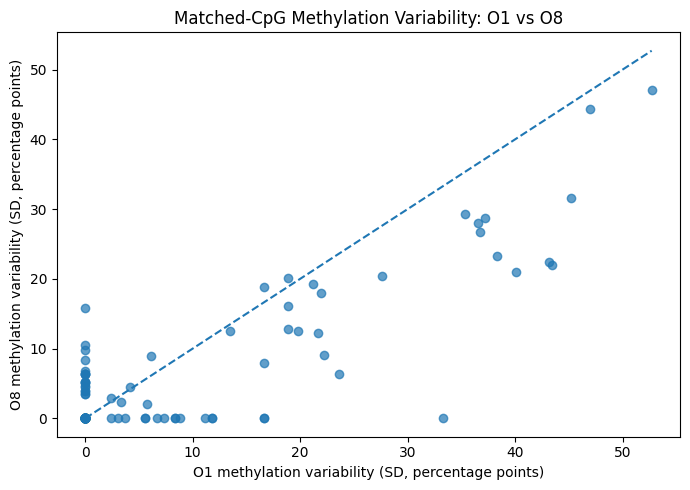

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(o1_sd, o8_sd, alpha=0.7)

max_val = max(o1_sd.max(), o8_sd.max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("O1 methylation variability (SD, percentage points)")
plt.ylabel("O8 methylation variability (SD, percentage points)")
plt.title("Matched-CpG Methylation Variability: O1 vs O8")

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "/content/o1_vs_o8_matched_variability.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved.")

Figure saved.


<Figure size 640x480 with 0 Axes>

In [ ]:
import os

os.makedirs("/content/methylation_data/Y2", exist_ok=True)

print("Y2 folder ready:",
      os.path.exists("/content/methylation_data/Y2"))

Y2 folder ready: True


In [ ]:
import os

y2_urls = {
    "GSM3436352_Y2_TA_Hi_10.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436352/suppl/GSM3436352_Y2_TA_Hi_10.cov.gz",
    "GSM3436353_Y2_TA_Hi_11.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436353/suppl/GSM3436353_Y2_TA_Hi_11.cov.gz",
    "GSM3436354_Y2_TA_Hi_12.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436354/suppl/GSM3436354_Y2_TA_Hi_12.cov.gz",
    "GSM3436355_Y2_TA_Hi_13.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436355/suppl/GSM3436355_Y2_TA_Hi_13.cov.gz",
    "GSM3436356_Y2_TA_Hi_14.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436356/suppl/GSM3436356_Y2_TA_Hi_14.cov.gz",
    "GSM3436357_Y2_TA_Hi_15.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436357/suppl/GSM3436357_Y2_TA_Hi_15.cov.gz",
    "GSM3436358_Y2_TA_Hi_17.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436358/suppl/GSM3436358_Y2_TA_Hi_17.cov.gz",
    "GSM3436359_Y2_TA_Hi_19.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436359/suppl/GSM3436359_Y2_TA_Hi_19.cov.gz",
    "GSM3436360_Y2_TA_Hi_1.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436360/suppl/GSM3436360_Y2_TA_Hi_1.cov.gz",
    "GSM3436361_Y2_TA_Hi_20.cov.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436361/suppl/GSM3436361_Y2_TA_Hi_20.cov.gz"
}

for filename, url in y2_urls.items():
    output = f"/content/methylation_data/Y2/{filename}"
    print("Downloading:", filename)

Downloading: GSM3436352_Y2_TA_Hi_10.cov.gz
Downloading: GSM3436353_Y2_TA_Hi_11.cov.gz
Downloading: GSM3436354_Y2_TA_Hi_12.cov.gz
Downloading: GSM3436355_Y2_TA_Hi_13.cov.gz
Downloading: GSM3436356_Y2_TA_Hi_14.cov.gz
Downloading: GSM3436357_Y2_TA_Hi_15.cov.gz
Downloading: GSM3436358_Y2_TA_Hi_17.cov.gz
Downloading: GSM3436359_Y2_TA_Hi_19.cov.gz
Downloading: GSM3436360_Y2_TA_Hi_1.cov.gz
Downloading: GSM3436361_Y2_TA_Hi_20.cov.gz


In [ ]:
import glob
import gzip
import os

y2_files = sorted(
    glob.glob("/content/methylation_data/Y2/*.cov.gz")
)

print("Y2 files:", len(y2_files))

for f in y2_files:
    try:
        with gzip.open(f, "rt") as gz:
            line = gz.readline().strip()
        print("GOOD:", os.path.basename(f), "→", line)
    except Exception as e:
        print("BAD:", os.path.basename(f), "→", type(e).__name__)

Y2 files: 0


In [ ]:
import os

print(os.listdir("/content/methylation_data/Y2"))

[]


In [ ]:
import os

url = "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436352/suppl/GSM3436352_Y2_TA_Hi_10.cov.gz"
out = "/content/methylation_data/Y2/test_Y2.cov.gz"

os.system(f'curl -L --retry 5 --retry-delay 2 "{url}" -o "{out}"')

print("File exists:", os.path.exists(out))
print("File size:", os.path.getsize(out) if os.path.exists(out) else 0)

File exists: True
File size: 8318402


In [ ]:
import os

url = "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436353/suppl/GSM3436353_Y2_TA_Hi_11.cov.gz"
out = "/content/methylation_data/Y2/GSM3436353_Y2_TA_Hi_11.cov.gz"

os.system(f'curl -L --retry 10 --retry-delay 2 "{url}" -o "{out}"')

print("Downloaded:", os.path.exists(out))
print("Size:", os.path.getsize(out) if os.path.exists(out) else 0)

Downloaded: True
Size: 980


In [ ]:
import os

bad = "/content/methylation_data/Y2/GSM3436353_Y2_TA_Hi_11.cov.gz"

if os.path.exists(bad):
    os.remove(bad)

print("Bad file removed:", not os.path.exists(bad))

Bad file removed: True


In [ ]:
import gzip

test = "/content/methylation_data/Y2/test_Y2.cov.gz"

with gzip.open(test, "rt") as f:
    print(f.readline().strip())

1	3048462	3048462	0.00	0	1


In [ ]:
import os

url = "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436353/suppl/GSM3436353_Y2_TA_Hi_11.cov.gz"
tmp = "/content/methylation_data/Y2/Hi_11.tmp"
final = "/content/methylation_data/Y2/GSM3436353_Y2_TA_Hi_11.cov.gz"

os.system(
    f'curl -L --retry 10 --retry-delay 3 --retry-all-errors '
    f'"{url}" -o "{tmp}"'
)

size = os.path.getsize(tmp) if os.path.exists(tmp) else 0
print("Downloaded size:", size)

if size > 1_000_000:
    os.rename(tmp, final)
    print("Hi_11 accepted.")
else:
    if os.path.exists(tmp):
        os.remove(tmp)
    print("Hi_11 rejected — download was too small.")

Downloaded size: 7832346
Hi_11 accepted.


In [ ]:
import os

url = "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/GSM3436354/suppl/GSM3436354_Y2_TA_Hi_12.cov.gz"
tmp = "/content/methylation_data/Y2/Hi_12.tmp"
final = "/content/methylation_data/Y2/GSM3436354_Y2_TA_Hi_12.cov.gz"

os.system(
    f'curl -L --retry 10 --retry-delay 3 --retry-all-errors '
    f'"{url}" -o "{tmp}"'
)

size = os.path.getsize(tmp) if os.path.exists(tmp) else 0
print("Downloaded size:", size)

if size > 1_000_000:
    os.rename(tmp, final)
    print("Hi_12 accepted.")
else:
    if os.path.exists(tmp):
        os.remove(tmp)
    print("Hi_12 rejected — download was too small.")

Downloaded size: 7015644
Hi_12 accepted.


In [ ]:
import os

remaining_y2 = {
    "13": ("GSM3436355", "GSM3436355_Y2_TA_Hi_13.cov.gz"),
    "14": ("GSM3436356", "GSM3436356_Y2_TA_Hi_14.cov.gz"),
    "15": ("GSM3436357", "GSM3436357_Y2_TA_Hi_15.cov.gz"),
    "17": ("GSM3436358", "GSM3436358_Y2_TA_Hi_17.cov.gz"),
    "19": ("GSM3436359", "GSM3436359_Y2_TA_Hi_19.cov.gz"),
    "1":  ("GSM3436360", "GSM3436360_Y2_TA_Hi_1.cov.gz"),
    "20": ("GSM3436361", "GSM3436361_Y2_TA_Hi_20.cov.gz")
}

for cell, (gsm, filename) in remaining_y2.items():
    url = f"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3436nnn/{gsm}/suppl/{filename}"
    tmp = f"/content/methylation_data/Y2/{filename}.tmp"
    final = f"/content/methylation_data/Y2/{filename}"

    print(f"Downloading Hi_{cell}...")

    os.system(
        f'curl -L --retry 10 --retry-delay 3 --retry-all-errors '
        f'"{url}" -o "{tmp}" -sS'
    )

    size = os.path.getsize(tmp) if os.path.exists(tmp) else 0

    if size > 1_000_000:
        os.replace(tmp, final)
        print(f"  ACCEPTED: {size:,} bytes")
    else:
        if os.path.exists(tmp):
            os.remove(tmp)
        print(f"  REJECTED: {size:,} bytes")

print("\nFinal Y2 files:",
      len([f for f in os.listdir("/content/methylation_data/Y2")
           if f.endswith(".cov.gz")]))

  ACCEPTED: 6,377,399 bytes
  ACCEPTED: 6,149,839 bytes
  ACCEPTED: 5,949,370 bytes
  ACCEPTED: 6,286,164 bytes
  ACCEPTED: 6,320,207 bytes
  ACCEPTED: 8,579,941 bytes
  ACCEPTED: 7,326,427 bytes

Final Y2 files: 10


In [ ]:
import glob
import gzip
import os

y2_files = sorted(
    glob.glob("/content/methylation_data/Y2/*.cov.gz")
)

print("Y2 files:", len(y2_files))

for f in y2_files:
    try:
        with gzip.open(f, "rt") as gz:
            line = gz.readline().strip()
        print("GOOD:", os.path.basename(f), "→", line)
    except Exception as e:
        print("BAD:", os.path.basename(f), "→", type(e).__name__)

Y2 files: 10
GOOD: GSM3436353_Y2_TA_Hi_11.cov.gz → 1	3003227	3003227	100.00	1	0
GOOD: GSM3436354_Y2_TA_Hi_12.cov.gz → 1	3001277	3001277	0.00	0	2
GOOD: GSM3436355_Y2_TA_Hi_13.cov.gz → 1	3000827	3000827	100.00	1	0
GOOD: GSM3436356_Y2_TA_Hi_14.cov.gz → 1	3003646	3003646	0.00	0	1
GOOD: GSM3436357_Y2_TA_Hi_15.cov.gz → 1	3003339	3003339	100.00	1	0
GOOD: GSM3436358_Y2_TA_Hi_17.cov.gz → 1	3020396	3020396	100.00	1	0
GOOD: GSM3436359_Y2_TA_Hi_19.cov.gz → 1	3003899	3003899	100.00	1	0
GOOD: GSM3436360_Y2_TA_Hi_1.cov.gz → 1	3003721	3003721	100.00	1	0
GOOD: GSM3436361_Y2_TA_Hi_20.cov.gz → 1	3000827	3000827	0.00	0	3
GOOD: test_Y2.cov.gz → 1	3048462	3048462	0.00	0	1


In [ ]:
from collections import Counter
import gzip

y2_cpg_counts = Counter()

for f in y2_files:
    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 3:
                chrom = parts[0]
                pos = int(parts[1])
                y2_cpg_counts[(chrom, pos)] += 1

print("Total unique Y2 CpGs:", len(y2_cpg_counts))
print("CpGs covered in ≥8/10 cells:",
      sum(count >= 8 for count in y2_cpg_counts.values()))

Total unique Y2 CpGs: 9622730
CpGs covered in ≥8/10 cells: 5469


In [ ]:
y2_high = {
    cpg for cpg, count in y2_cpg_counts.items()
    if count >= 8
}

print("Y2 high-coverage CpGs:", len(y2_high))

Y2 high-coverage CpGs: 5469


In [ ]:
o1_o8_y2_common = o1_high & o8_high & y2_high

print("O1 high-coverage CpGs:", len(o1_high))
print("O8 high-coverage CpGs:", len(o8_high))
print("Y2 high-coverage CpGs:", len(y2_high))
print("Shared across O1 + O8 + Y2:", len(o1_o8_y2_common))

O1 high-coverage CpGs: 3198
O8 high-coverage CpGs: 505
Y2 high-coverage CpGs: 5469
Shared across O1 + O8 + Y2: 102


In [ ]:
import pandas as pd
import gzip
import os

common_cpgs = sorted(o1_o8_y2_common)

o1_y2_matrix = pd.DataFrame(index=common_cpgs)
o8_y2_matrix = pd.DataFrame(index=common_cpgs)
y2_common_matrix = pd.DataFrame(index=common_cpgs)

# O1
for f in o1_files:
    cell_name = os.path.basename(f).replace(".cov.gz", "")
    data = {}

    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 4:
                cpg = (parts[0], int(parts[1]))
                if cpg in o1_o8_y2_common:
                    data[cpg] = float(parts[3])

    o1_y2_matrix[cell_name] = pd.Series(data)

# O8
for f in o8_files:
    cell_name = os.path.basename(f).replace(".cov.gz", "")
    data = {}

    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 4:
                cpg = (parts[0], int(parts[1]))
                if cpg in o1_o8_y2_common:
                    data[cpg] = float(parts[3])

    o8_y2_matrix[cell_name] = pd.Series(data)

# Y2
for f in y2_files:
    cell_name = os.path.basename(f).replace(".cov.gz", "")
    data = {}

    with gzip.open(f, "rt") as gz:
        for line in gz:
            parts = line.rstrip().split("\t")
            if len(parts) >= 4:
                cpg = (parts[0], int(parts[1]))
                if cpg in o1_o8_y2_common:
                    data[cpg] = float(parts[3])

    y2_common_matrix[cell_name] = pd.Series(data)

print("O1 matrix:", o1_y2_matrix.shape)
print("O8 matrix:", o8_y2_matrix.shape)
print("Y2 matrix:", y2_common_matrix.shape)

O1 matrix: (102, 9)
O8 matrix: (102, 10)
Y2 matrix: (102, 10)


In [ ]:
# Per-CpG methylation variability across cells

o1_sd_102 = o1_y2_matrix.std(axis=1, skipna=True)
o8_sd_102 = o8_y2_matrix.std(axis=1, skipna=True)
y2_sd_102 = y2_common_matrix.std(axis=1, skipna=True)

print("O1 variability:")
print(o1_sd_102.describe())

print("\nO8 variability:")
print(o8_sd_102.describe())

print("\nY2 variability:")
print(y2_sd_102.describe())

O1 variability:
count    102.000000
mean       6.915402
std       12.913452
min        0.000000
25%        0.000000
50%        0.000000
75%        7.179751
max       52.704628
dtype: float64

O8 variability:
count    102.000000
mean       5.250722
std        9.607356
min        0.000000
25%        0.000000
50%        0.000000
75%        6.061296
max       47.140789
dtype: float64

Y2 variability:
count    102.000000
mean       7.981780
std       12.366223
min        0.000000
25%        0.000000
50%        0.000000
75%       13.168355
max       49.721446
dtype: float64


In [ ]:
print("Mean Y2 - O1:", (y2_sd_102 - o1_sd_102).mean())
print("Mean Y2 - O8:", (y2_sd_102 - o8_sd_102).mean())
print("Mean O8 - O1:", (o8_sd_102 - o1_sd_102).mean())

print("\nY2 > O1:", (y2_sd_102 > o1_sd_102).sum())
print("O1 > Y2:", (o1_sd_102 > y2_sd_102).sum())
print("Equal Y2/O1:", (y2_sd_102 == o1_sd_102).sum())

print("\nY2 > O8:", (y2_sd_102 > o8_sd_102).sum())
print("O8 > Y2:", (o8_sd_102 > y2_sd_102).sum())
print("Equal Y2/O8:", (y2_sd_102 == o8_sd_102).sum())

Mean Y2 - O1: 1.0663783946794414
Mean Y2 - O8: 2.7310576679984133
Mean O8 - O1: -1.6646792733189715

Y2 > O1: 30
O1 > Y2: 21
Equal Y2/O1: 51

Y2 > O8: 37
O8 > Y2: 18
Equal Y2/O8: 47


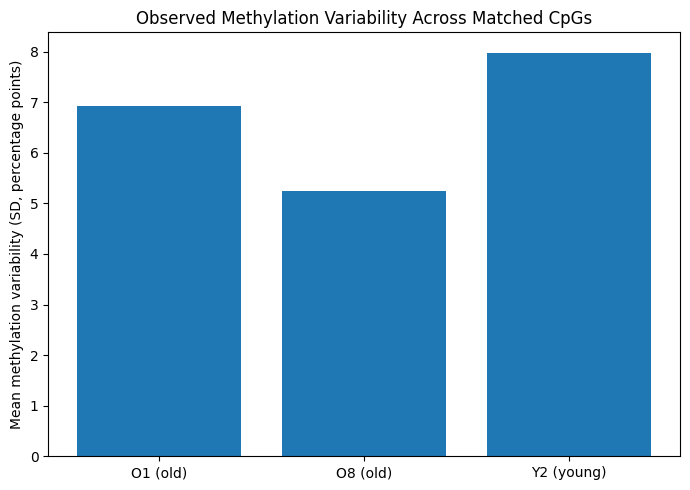

In [ ]:
import matplotlib.pyplot as plt

means = [
    o1_sd_102.mean(),
    o8_sd_102.mean(),
    y2_sd_102.mean()
]

labels = ["O1 (old)", "O8 (old)", "Y2 (young)"]

plt.figure(figsize=(7, 5))

plt.bar(labels, means)

plt.ylabel("Mean methylation variability (SD, percentage points)")
plt.title("Observed Methylation Variability Across Matched CpGs")

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "/content/o1_o8_y2_variability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Three-mouse figure saved.")

Three-mouse figure saved.


<Figure size 640x480 with 0 Axes>

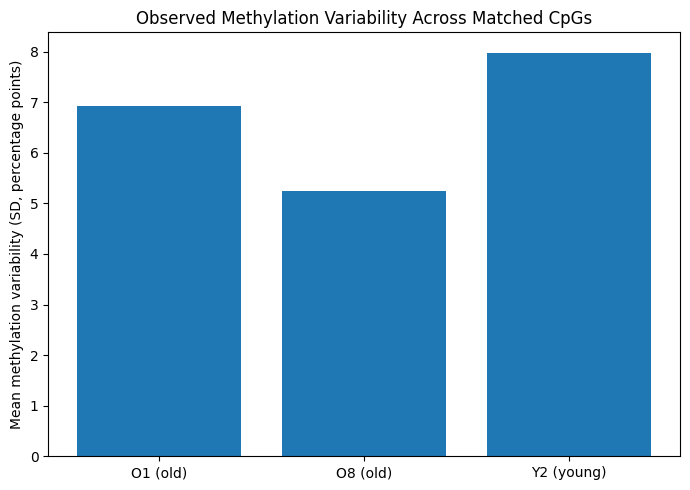

Figure saved correctly.


In [ ]:
import matplotlib.pyplot as plt

means = [
    o1_sd_102.mean(),
    o8_sd_102.mean(),
    y2_sd_102.mean()
]

labels = ["O1 (old)", "O8 (old)", "Y2 (young)"]

plt.figure(figsize=(7, 5))
plt.bar(labels, means)
plt.ylabel("Mean methylation variability (SD, percentage points)")
plt.title("Observed Methylation Variability Across Matched CpGs")
plt.tight_layout()

plt.savefig(
    "/content/o1_o8_y2_variability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved correctly.")

In [ ]:
import pandas as pd

results_summary = pd.DataFrame({
    "Mouse": ["O1", "O8", "Y2"],
    "Age_group": ["Old", "Old", "Young"],
    "Matched_CpGs": [102, 102, 102],
    "Mean_SD_pp": [
        o1_sd_102.mean(),
        o8_sd_102.mean(),
        y2_sd_102.mean()
    ],
    "Median_SD_pp": [
        o1_sd_102.median(),
        o8_sd_102.median(),
        y2_sd_102.median()
    ]
})

results_summary

,Mouse,Age_group,Matched_CpGs,Mean_SD_pp,Median_SD_pp
0,O1,Old,102,6.915402,0.0
1,O8,Old,102,5.250722,0.0
2,Y2,Young,102,7.981780,0.0


## Results and Interpretation

Across matched high-coverage CpGs, observed methylation variability was quantified as the standard deviation (SD) of methylation percentages across cells.

A total of 102 CpGs were covered in at least 8 cells in each of the three analyzed mice (O1, O8, and Y2). The mean observed variability was 6.92 percentage points in O1, 5.25 percentage points in O8, and 7.98 percentage points in Y2.

Y2 showed the highest mean observed variability among the three mice, while O8 showed the lowest. However, these comparisons are descriptive because the cells are nested within individual mice and the current analysis includes only one young mouse and two old mice. Therefore, the results do not establish an age-associated effect.

The high number of zero median SD values also indicates that many matched CpGs showed little or no observed cell-to-cell variation in this dataset. These results should therefore be interpreted as an exploratory assessment of methylation variability rather than evidence of a statistically established aging effect.

## Limitations

- The dataset contains a small number of biological replicates, so the present comparison is descriptive rather than inferential.
- Cells are nested within individual mice and should not be treated as independent biological replicates.
- scBS-seq data are sparse, with many CpGs observed in only a subset of cells.
- Missing CpG observations were retained as missing values rather than interpreted as unmethylated.
- The matched analysis was restricted to CpGs meeting the coverage criterion in all three mice, resulting in 102 shared CpGs.
- Therefore, the observed differences in methylation variability should not be interpreted as a definitive age-associated effect.

In [ ]:
import os

for f in [
    "/content/o1_o8_y2_variability_comparison.png",
        "/content/o1_vs_o8_matched_variability.png"
        ]:
            print(f, "→", os.path.exists(f))

/content/o1_o8_y2_variability_comparison.png → True
/content/o1_vs_o8_matched_variability.png → True


In [ ]:
from google.colab import files

files.download("/content/o1_o8_y2_variability_comparison.png")
files.download("/content/o1_vs_o8_matched_variability.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>